# Phase 2: Exhaustive Exploratory Data Analysis


This notebook constitutes the most critical pre-modeling phase of the Hybrid Temporal Forecaster. Before applying any machine learning algorithm, we must develop a deep, intuitive understanding of the data we are working with. This EDA is structured in 15 analytical sections, each designed to expose a different facet of the financial time-series -- from basic statistical properties to advanced temporal dependencies and cross-asset dynamics.


We analyze both the **Strategic Daily** (20-year) and **Tactical Hourly** (2-year) datasets to understand how statistical properties change across temporal granularities.

## 1. Imports and Reproducibility


We load all necessary libraries upfront. The visualization style is set to a dark, publication-quality theme for consistency across all plots. The seed is established for any stochastic operations (e.g., bootstrap sampling in later sections).

In [1]:
import pandas as pd
import numpy as np
import random
import os
import warnings
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from itertools import combinations

warnings.filterwarnings('ignore')

SEED = 25
np.random.seed(SEED)
random.seed(SEED)

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'lines.linewidth': 1.5,
    'figure.dpi': 100
})

TICKERS = ["AAPL", "MSFT", "JPM", "SPY", "GLD"]
DAILY_DIR = "../data/raw/daily"
HOURLY_DIR = "../data/raw/hourly"

print(f"Seed: {SEED}")
print(f"Tickers: {TICKERS}")

Seed: 25
Tickers: ['AAPL', 'MSFT', 'JPM', 'SPY', 'GLD']


## 2. Data Loading and Structural Inspection


We load all CSV files into two dictionaries -- one for daily, one for hourly data. The yfinance library produces multi-level headers, so we must handle column parsing carefully. After loading, we inspect the shape, date ranges, and basic integrity of each dataset.

In [2]:
def load_data(data_dir, tickers):
    """Load CSV files from a directory into a dictionary of DataFrames."""
    data = {}
    for ticker in tickers:
        path = os.path.join(data_dir, f"{ticker}.csv")
        df = pd.read_csv(path, header=[0, 1], index_col=0, parse_dates=True)
        df.columns = df.columns.get_level_values(0)
        data[ticker] = df
    return data

daily_data = load_data(DAILY_DIR, TICKERS)
hourly_data = load_data(HOURLY_DIR, TICKERS)

print("=== Daily Data Summary ===")
for t, df in daily_data.items():
    print(f"  {t}: {df.shape[0]} rows, {df.index[0].date()} to {df.index[-1].date()}")

print("\n=== Hourly Data Summary ===")
for t, df in hourly_data.items():
    print(f"  {t}: {df.shape[0]} rows, {df.index[0]} to {df.index[-1]}")

=== Daily Data Summary ===
  AAPL: 5028 rows, 2006-03-27 to 2026-03-20
  MSFT: 5028 rows, 2006-03-27 to 2026-03-20
  JPM: 5028 rows, 2006-03-27 to 2026-03-20
  SPY: 5028 rows, 2006-03-27 to 2026-03-20
  GLD: 5028 rows, 2006-03-27 to 2026-03-20

=== Hourly Data Summary ===
  AAPL: 3460 rows, 2024-03-25 13:30:00+00:00 to 2026-03-20 19:30:00+00:00
  MSFT: 3460 rows, 2024-03-25 13:30:00+00:00 to 2026-03-20 19:30:00+00:00
  JPM: 3459 rows, 2024-03-25 13:30:00+00:00 to 2026-03-20 19:30:00+00:00
  SPY: 3459 rows, 2024-03-25 13:30:00+00:00 to 2026-03-20 19:30:00+00:00
  GLD: 3459 rows, 2024-03-25 13:30:00+00:00 to 2026-03-20 19:30:00+00:00


## 3. Missing Values and Data Quality Audit


Financial data is rarely perfectly clean. Gaps can arise from market holidays, trading halts, or API errors. We quantify missingness across all assets and horizons to decide on an imputation or forward-fill strategy before any computation.

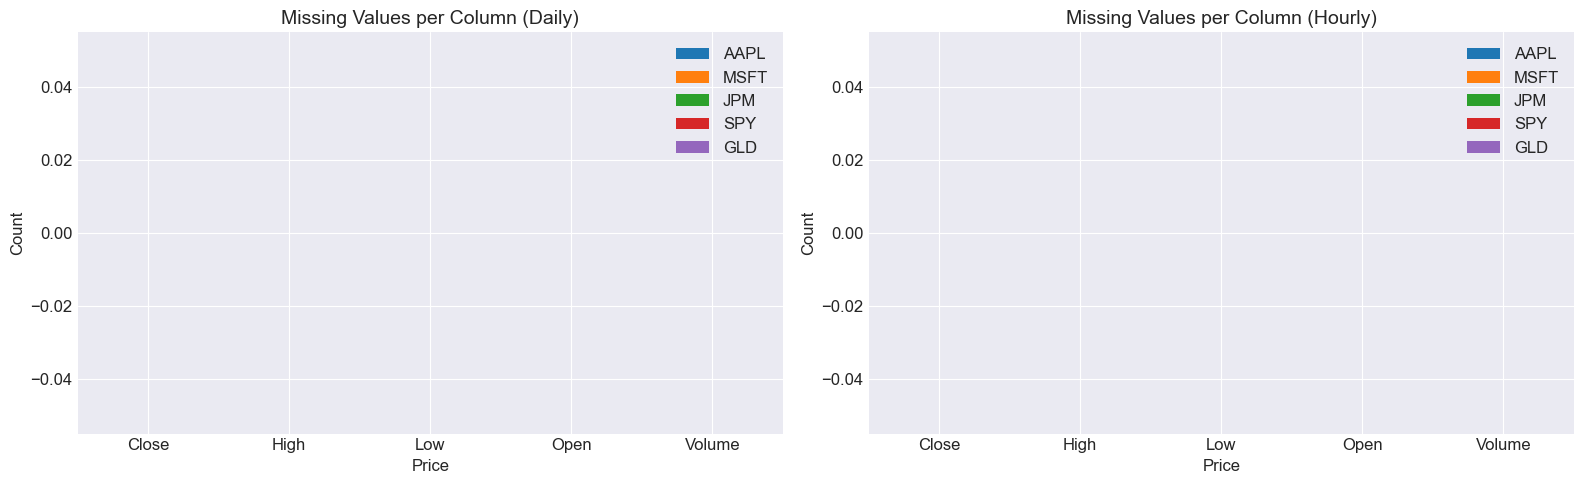

Daily total missing per ticker: {'AAPL': np.int64(0), 'MSFT': np.int64(0), 'JPM': np.int64(0), 'SPY': np.int64(0), 'GLD': np.int64(0)}
Hourly total missing per ticker: {'AAPL': np.int64(0), 'MSFT': np.int64(0), 'JPM': np.int64(0), 'SPY': np.int64(0), 'GLD': np.int64(0)}


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Daily missing values
daily_missing = pd.DataFrame({t: df.isnull().sum() for t, df in daily_data.items()})
daily_missing.plot(kind='bar', ax=axes[0], rot=0)
axes[0].set_title('Missing Values per Column (Daily)')
axes[0].set_ylabel('Count')

# Hourly missing values
hourly_missing = pd.DataFrame({t: df.isnull().sum() for t, df in hourly_data.items()})
hourly_missing.plot(kind='bar', ax=axes[1], rot=0)
axes[1].set_title('Missing Values per Column (Hourly)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Summary statistics
print("Daily total missing per ticker:", {t: df.isnull().sum().sum() for t, df in daily_data.items()})
print("Hourly total missing per ticker:", {t: df.isnull().sum().sum() for t, df in hourly_data.items()})

## 4. Price Time-Series Visualization


The most fundamental view of our data. We plot the closing prices of all 5 assets on both daily and hourly horizons. Because price scales differ vastly (GLD trades around 200, SPY around 500, AAPL around 200), we use normalized prices (indexed to 100 at the start) to compare relative performance.

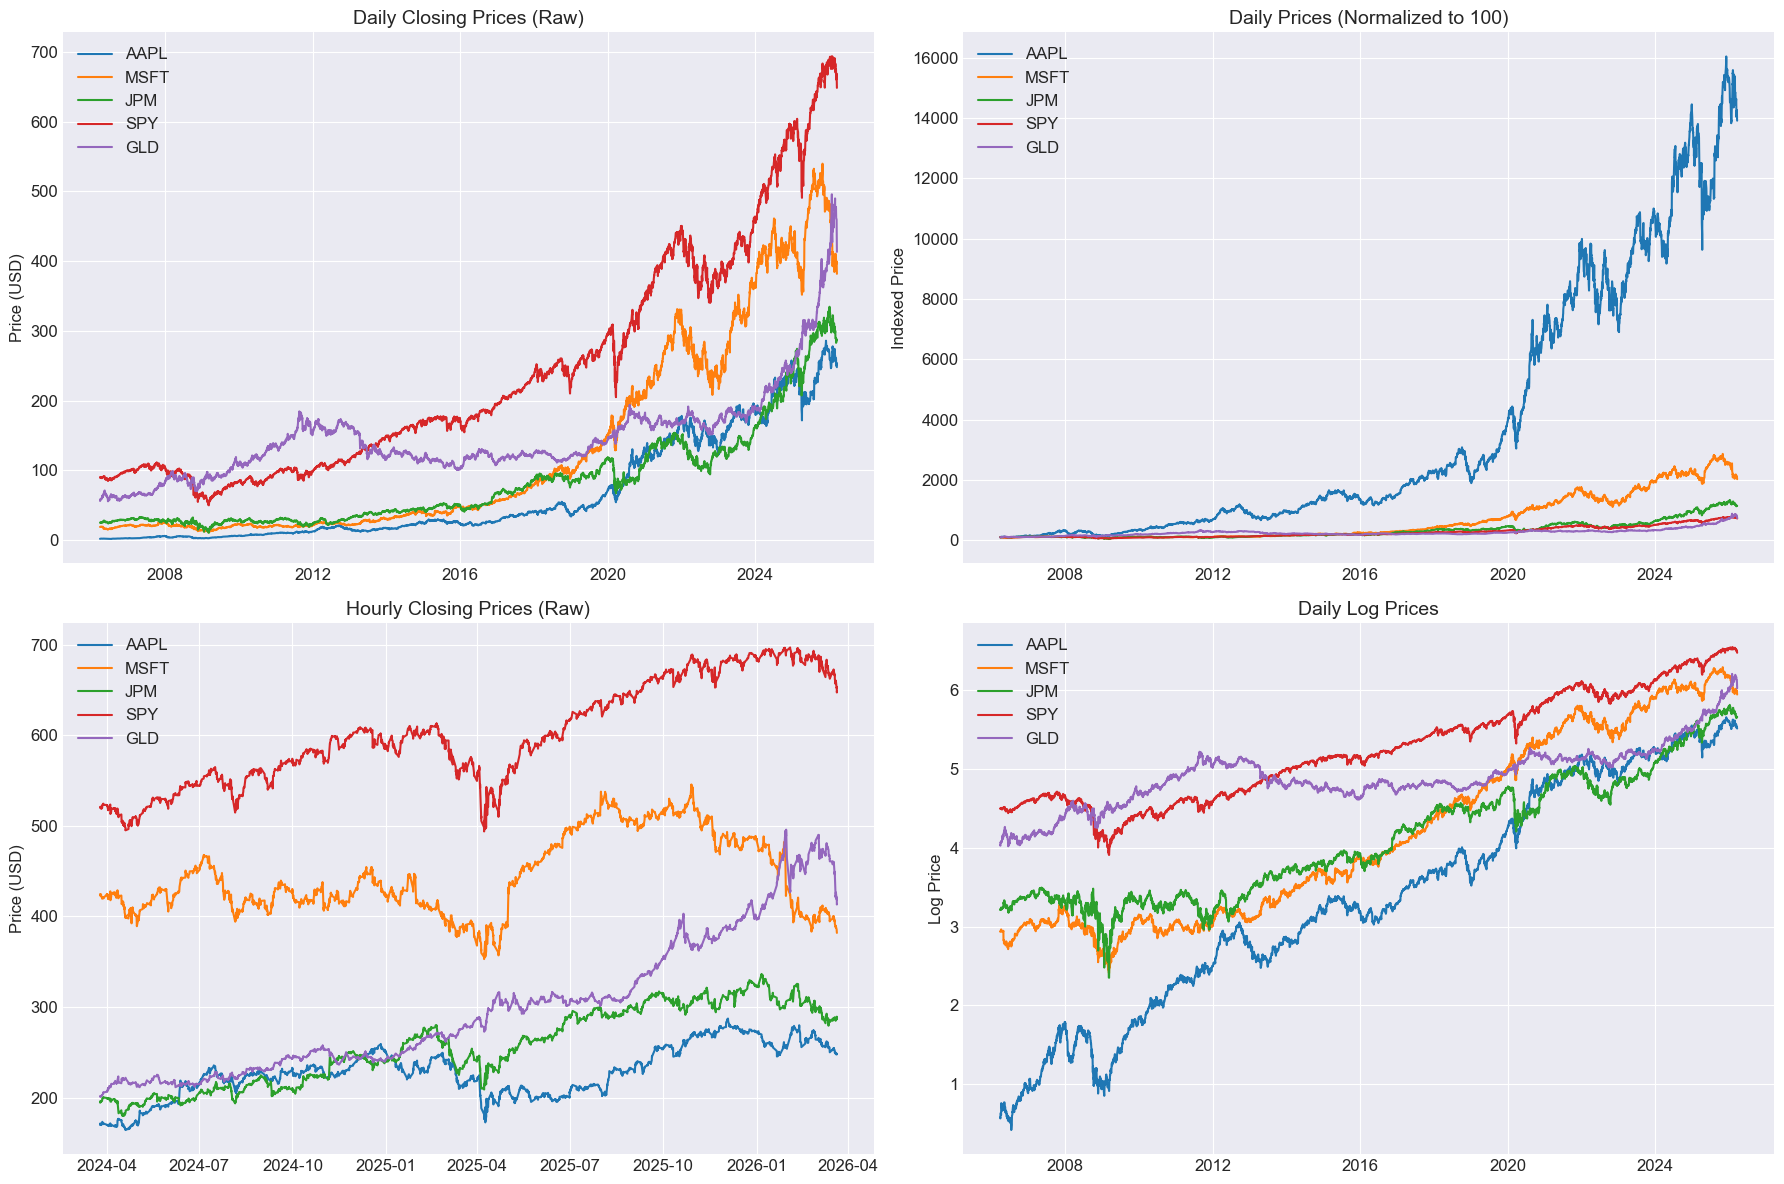

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Raw daily prices
for t, df in daily_data.items():
    axes[0, 0].plot(df.index, df['Close'], label=t)
axes[0, 0].set_title('Daily Closing Prices (Raw)')
axes[0, 0].legend()
axes[0, 0].set_ylabel('Price (USD)')

# Normalized daily prices
for t, df in daily_data.items():
    normalized = df['Close'] / df['Close'].iloc[0] * 100
    axes[0, 1].plot(df.index, normalized, label=t)
axes[0, 1].set_title('Daily Prices (Normalized to 100)')
axes[0, 1].legend()
axes[0, 1].set_ylabel('Indexed Price')

# Raw hourly prices
for t, df in hourly_data.items():
    axes[1, 0].plot(df.index, df['Close'], label=t)
axes[1, 0].set_title('Hourly Closing Prices (Raw)')
axes[1, 0].legend()
axes[1, 0].set_ylabel('Price (USD)')

# Log daily prices
for t, df in daily_data.items():
    axes[1, 1].plot(df.index, np.log(df['Close']), label=t)
axes[1, 1].set_title('Daily Log Prices')
axes[1, 1].legend()
axes[1, 1].set_ylabel('Log Price')

plt.tight_layout()
plt.show()

## 5. Returns Computation and Distribution Analysis


Raw prices are non-stationary and not directly usable for most ML models. We compute simple returns ($r_t = P_t / P_{t-1} - 1$) and log returns ($r_t = \ln(P_t / P_{t-1})$) for both horizons. Log returns are preferred in quantitative finance because they are time-additive and better approximate a normal distribution for small changes.

In [5]:
# Compute returns for all assets
daily_returns = {}
daily_log_returns = {}
hourly_returns = {}
hourly_log_returns = {}

for t in TICKERS:
    daily_returns[t] = daily_data[t]['Close'].pct_change().dropna()
    daily_log_returns[t] = np.log(daily_data[t]['Close'] / daily_data[t]['Close'].shift(1)).dropna()
    hourly_returns[t] = hourly_data[t]['Close'].pct_change().dropna()
    hourly_log_returns[t] = np.log(hourly_data[t]['Close'] / hourly_data[t]['Close'].shift(1)).dropna()

# Summary statistics table
summary = []
for t in TICKERS:
    for horizon, rets in [("Daily", daily_returns[t]), ("Hourly", hourly_returns[t])]:
        summary.append({
            "Ticker": t,
            "Horizon": horizon,
            "Mean": f"{rets.mean():.6f}",
            "Std": f"{rets.std():.6f}",
            "Skewness": f"{rets.skew():.4f}",
            "Kurtosis": f"{rets.kurtosis():.4f}",
            "Min": f"{rets.min():.4f}",
            "Max": f"{rets.max():.4f}",
            "Count": len(rets)
        })

pd.DataFrame(summary)

,Ticker,Horizon,Mean,Std,Skewness,Kurtosis,Min,Max,Count
0,AAPL,Daily,0.001180,0.019882,0.0318,6.3316,-0.1792,0.1533,5027
1,AAPL,Hourly,0.000131,0.006565,-0.0086,20.6727,-0.0811,0.0641,3459
2,MSFT,Daily,0.000750,0.017420,0.2194,9.5914,-0.1474,0.1860,5027
3,MSFT,Hourly,-0.000012,0.005990,-1.1944,71.5165,-0.1150,0.0987,3459
4,JPM,Daily,0.000750,0.023155,0.9187,18.9247,-0.2073,0.2510,5027
5,JPM,Hourly,0.000129,0.006218,0.0629,37.6234,-0.0723,0.0951,3458
6,SPY,Daily,0.000468,0.012228,0.0004,14.9228,-0.1094,0.1452,5027
7,SPY,Hourly,0.000071,0.003844,0.0127,25.5876,-0.0397,0.0495,3458
8,GLD,Daily,0.000463,0.011496,-0.3203,6.8978,-0.1027,0.1129,5027
9,GLD,Hourly,0.000221,0.005169,-2.4539,47.9585,-0.0806,0.0587,3458


## 6. Distribution Deep Dive: Histograms, KDE, and QQ-Plots


The Gaussian assumption underpins most classical finance models. Here, we test how well our returns follow a normal distribution. Financial returns are known to exhibit "fat tails" (leptokurtosis) -- extreme events occur far more frequently than a Gaussian model would predict. We use histograms with a Gaussian overlay, Kernel Density Estimation (KDE), and Quantile-Quantile (QQ) plots to visually diagnose departures from normality.

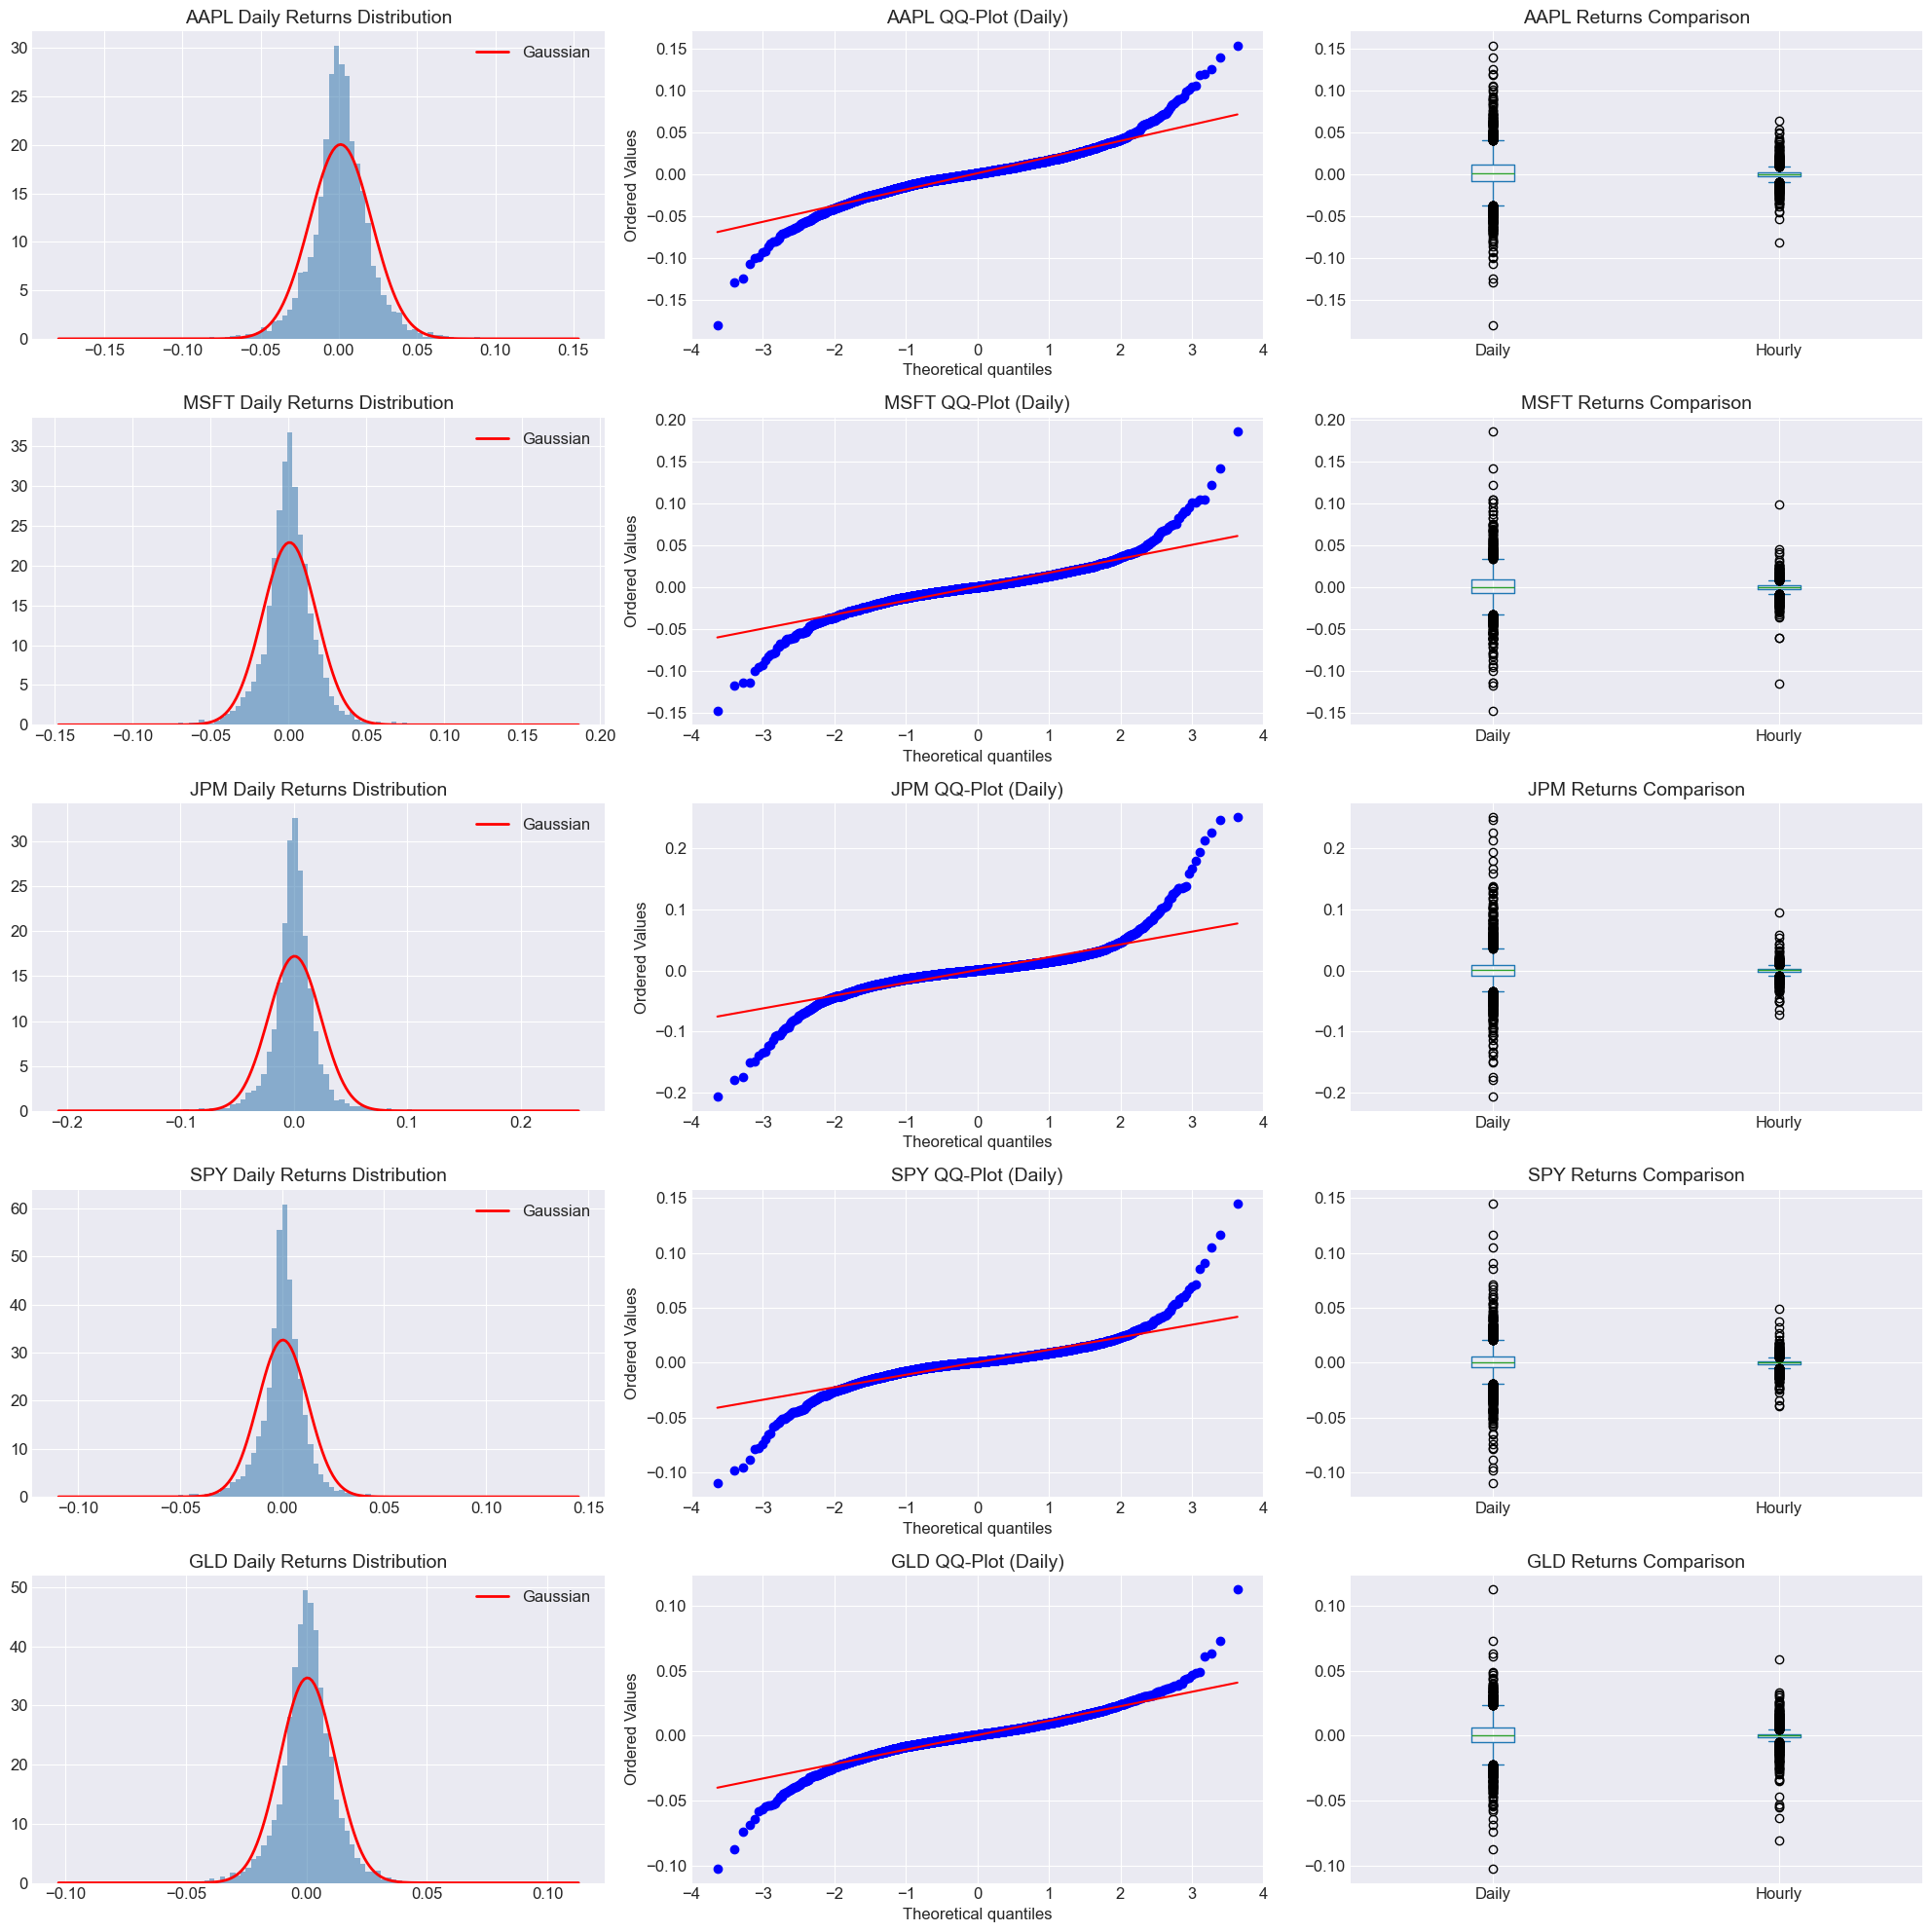

In [6]:
fig, axes = plt.subplots(len(TICKERS), 3, figsize=(20, 4 * len(TICKERS)))

for i, t in enumerate(TICKERS):
    rets = daily_returns[t]
    
    # Histogram + KDE
    axes[i, 0].hist(rets, bins=100, density=True, alpha=0.6, color='steelblue', edgecolor='none')
    x_range = np.linspace(rets.min(), rets.max(), 200)
    axes[i, 0].plot(x_range, stats.norm.pdf(x_range, rets.mean(), rets.std()), 'r-', lw=2, label='Gaussian')
    axes[i, 0].set_title(f'{t} Daily Returns Distribution')
    axes[i, 0].legend()
    
    # QQ Plot
    stats.probplot(rets, dist="norm", plot=axes[i, 1])
    axes[i, 1].set_title(f'{t} QQ-Plot (Daily)')
    
    # Box plot comparing daily vs hourly
    box_data = pd.DataFrame({'Daily': daily_returns[t].reset_index(drop=True), 
                              'Hourly': hourly_returns[t].reset_index(drop=True).iloc[:len(daily_returns[t])]})
    box_data.plot.box(ax=axes[i, 2])
    axes[i, 2].set_title(f'{t} Returns Comparison')

plt.tight_layout()
plt.show()

## 7. Formal Normality Testing


Visual inspection is useful but subjective. We apply three rigorous statistical tests to quantify the departure from normality:


1. **Jarque-Bera Test**: Tests whether the sample skewness and kurtosis match a normal distribution. Highly sensitive to fat tails.
2. **Shapiro-Wilk Test**: A powerful test for normality, though computationally limited to 5,000 samples (we subsample for daily data).
3. **D'Agostino-Pearson Test**: Combines skewness and kurtosis into a single omnibus test.


A p-value below 0.05 means we reject the null hypothesis that the data is normally distributed.

In [7]:
normality_results = []
for t in TICKERS:
    for horizon, rets in [("Daily", daily_returns[t]), ("Hourly", hourly_returns[t])]:
        jb_stat, jb_p = stats.jarque_bera(rets)
        sw_stat, sw_p = stats.shapiro(rets.sample(min(5000, len(rets)), random_state=SEED))
        dp_stat, dp_p = stats.normaltest(rets)
        
        normality_results.append({
            "Ticker": t, "Horizon": horizon,
            "JB Stat": f"{jb_stat:.2f}", "JB p": f"{jb_p:.2e}",
            "SW Stat": f"{sw_stat:.4f}", "SW p": f"{sw_p:.2e}",
            "DP Stat": f"{dp_stat:.2f}", "DP p": f"{dp_p:.2e}",
            "Normal?": "Yes" if jb_p > 0.05 else "No"
        })

pd.DataFrame(normality_results)

,Ticker,Horizon,JB Stat,JB p,SW Stat,SW p,DP Stat,DP p,Normal?
0,AAPL,Daily,8377.96,0.00e+00,0.9373,1.11e-41,663.98,6.60e-145,No
1,AAPL,Hourly,61405.24,0.00e+00,0.7986,2.21e-54,868.40,2.69e-189,No
2,MSFT,Daily,19266.47,0.00e+00,0.9133,7.82e-47,902.71,9.52e-197,No
3,MSFT,Hourly,735801.14,0.00e+00,0.7309,1.38e-59,1810.94,0.00e+00,No
4,JPM,Daily,75564.69,0.00e+00,0.8213,1.76e-59,1733.14,0.00e+00,No
5,JPM,Hourly,203347.48,0.00e+00,0.7559,8.42e-58,1076.43,1.80e-234,No
6,SPY,Daily,46543.87,0.00e+00,0.8684,6.05e-54,1087.25,8.08e-237,No
7,SPY,Hourly,94049.87,0.00e+00,0.7853,1.66e-55,942.87,1.81e-205,No
8,GLD,Daily,10028.62,0.00e+00,0.9412,1.07e-40,785.19,3.14e-171,No
9,GLD,Hourly,333881.00,0.00e+00,0.6547,3.05e-64,2435.44,0.00e+00,No


## 8. Stationarity Analysis (Augmented Dickey-Fuller Test)


Stationarity is a prerequisite for most time-series models. A stationary series has a constant mean, variance, and autocovariance over time. The Augmented Dickey-Fuller (ADF) test evaluates the null hypothesis that the series has a unit root (i.e., is non-stationary).


We test four transformations of each asset: raw prices, log prices, simple returns, and log returns. We expect raw and log prices to be non-stationary, while returns should be stationary. This is the exact tension that Fractional Differentiation (Phase 3) will resolve.

In [8]:
adf_results = []
for t in TICKERS:
    series_dict = {
        "Raw Price": daily_data[t]['Close'],
        "Log Price": np.log(daily_data[t]['Close']),
        "Simple Return": daily_returns[t],
        "Log Return": daily_log_returns[t]
    }
    for name, series in series_dict.items():
        result = adfuller(series.dropna(), maxlag=20)
        adf_results.append({
            "Ticker": t, "Series": name,
            "ADF Stat": f"{result[0]:.4f}",
            "p-value": f"{result[1]:.6f}",
            "Lags Used": result[2],
            "Stationary?": "Yes" if result[1] < 0.05 else "No"
        })

pd.DataFrame(adf_results)

,Ticker,Series,ADF Stat,p-value,Lags Used,Stationary?
0,AAPL,Raw Price,0.9554,0.993772,20,No
1,AAPL,Log Price,-1.1236,0.705587,16,No
2,AAPL,Simple Return,-16.9989,0.000000,15,Yes
3,AAPL,Log Return,-16.7923,0.000000,15,Yes
4,MSFT,Raw Price,0.2386,0.974345,20,No
5,MSFT,Log Price,0.2767,0.976249,9,No
6,MSFT,Simple Return,-25.5984,0.000000,8,Yes
7,MSFT,Log Return,-25.4327,0.000000,8,Yes
8,JPM,Raw Price,1.8195,0.998387,20,No
9,JPM,Log Price,0.1670,0.970348,20,No


## 9. Autocorrelation and Partial Autocorrelation


Autocorrelation measures the linear relationship between a time-series and its lagged values. In efficient markets, returns should show no autocorrelation (each return is independent of the previous one). However, **squared returns** often show strong autocorrelation, which is the signature of **volatility clustering** -- the tendency for large moves to follow large moves.


We plot ACF and PACF for both raw returns and squared returns to expose these hidden temporal dependencies.

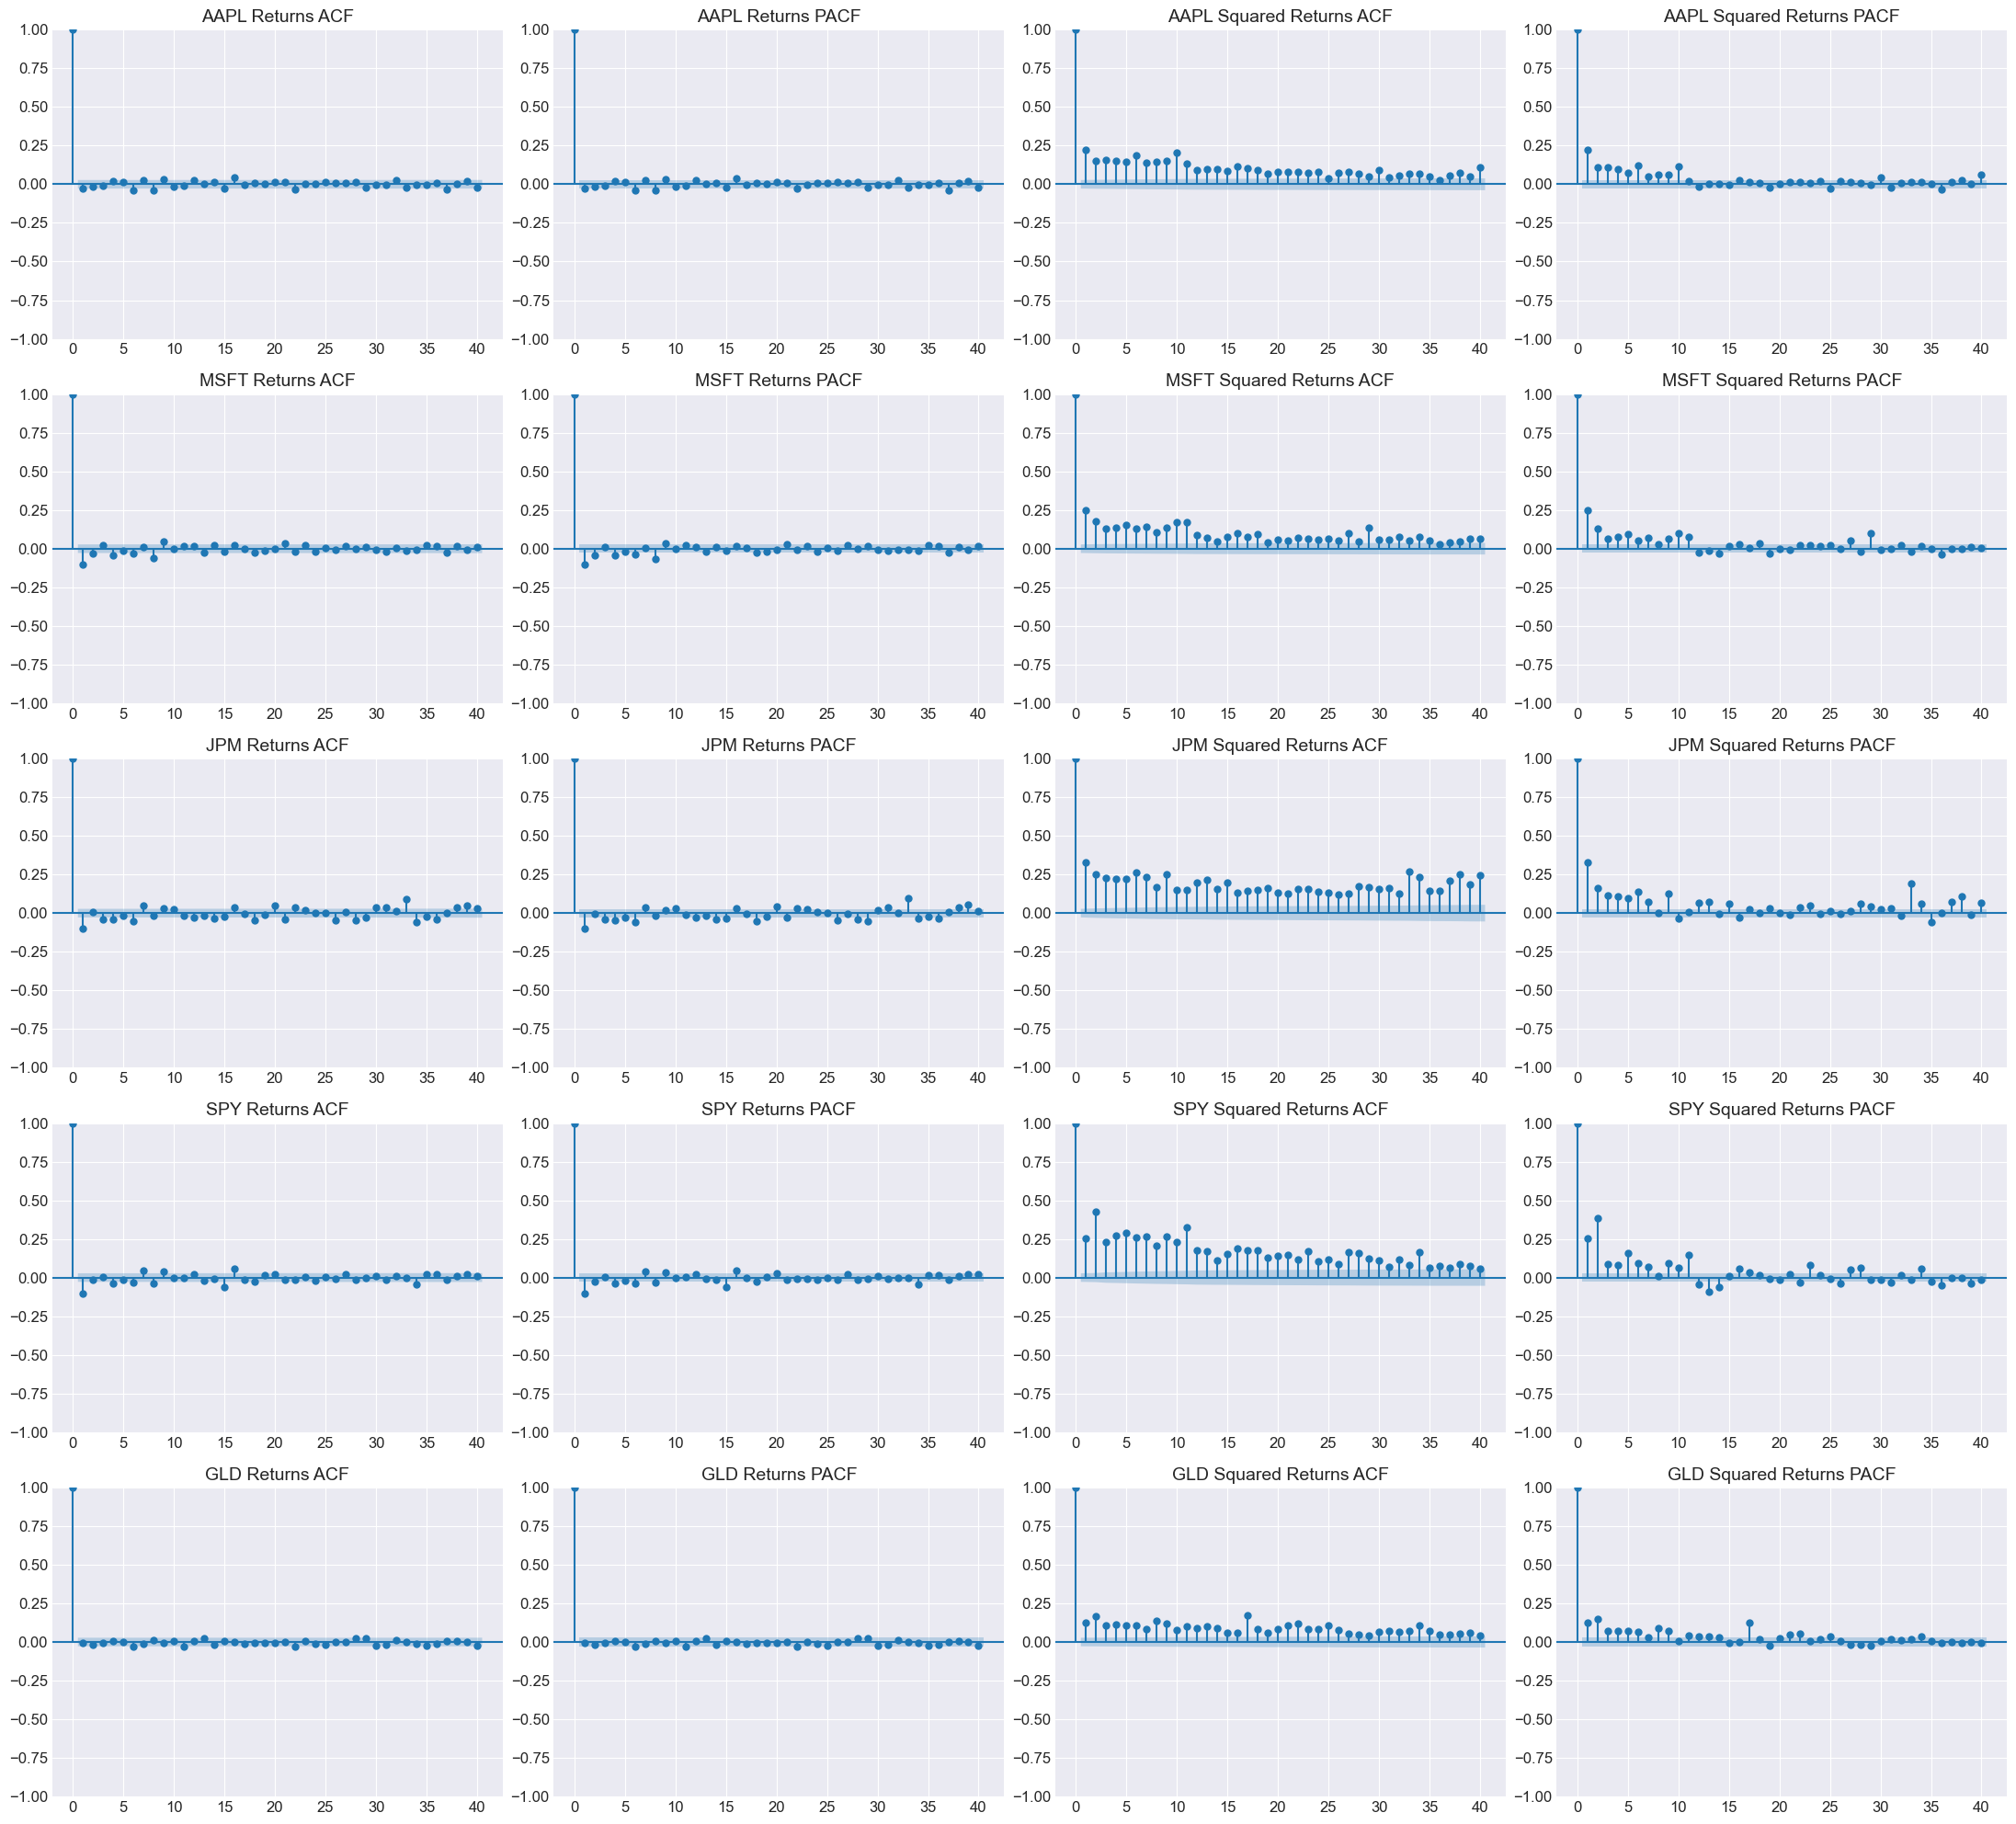

In [9]:
fig, axes = plt.subplots(len(TICKERS), 4, figsize=(22, 4 * len(TICKERS)))

for i, t in enumerate(TICKERS):
    rets = daily_returns[t]
    sq_rets = rets ** 2
    
    plot_acf(rets, lags=40, ax=axes[i, 0], title=f'{t} Returns ACF')
    plot_pacf(rets, lags=40, ax=axes[i, 1], title=f'{t} Returns PACF', method='ywm')
    plot_acf(sq_rets, lags=40, ax=axes[i, 2], title=f'{t} Squared Returns ACF')
    plot_pacf(sq_rets, lags=40, ax=axes[i, 3], title=f'{t} Squared Returns PACF', method='ywm')

plt.tight_layout()
plt.show()

## 10. Volatility Analysis and Clustering


Volatility is the heartbeat of financial markets. We compute rolling volatility (annualized standard deviation of returns over a 21-day window, roughly one trading month) to visualize how risk evolves over time. Key regime shifts -- the 2008 financial crisis, the 2020 COVID crash, and the 2022 rate hiking cycle -- should be clearly visible as volatility spikes.


We also compute the **Parkinson volatility estimator**, which uses high-low price ranges within each bar and is considered more efficient than close-to-close volatility because it captures intra-bar movement.

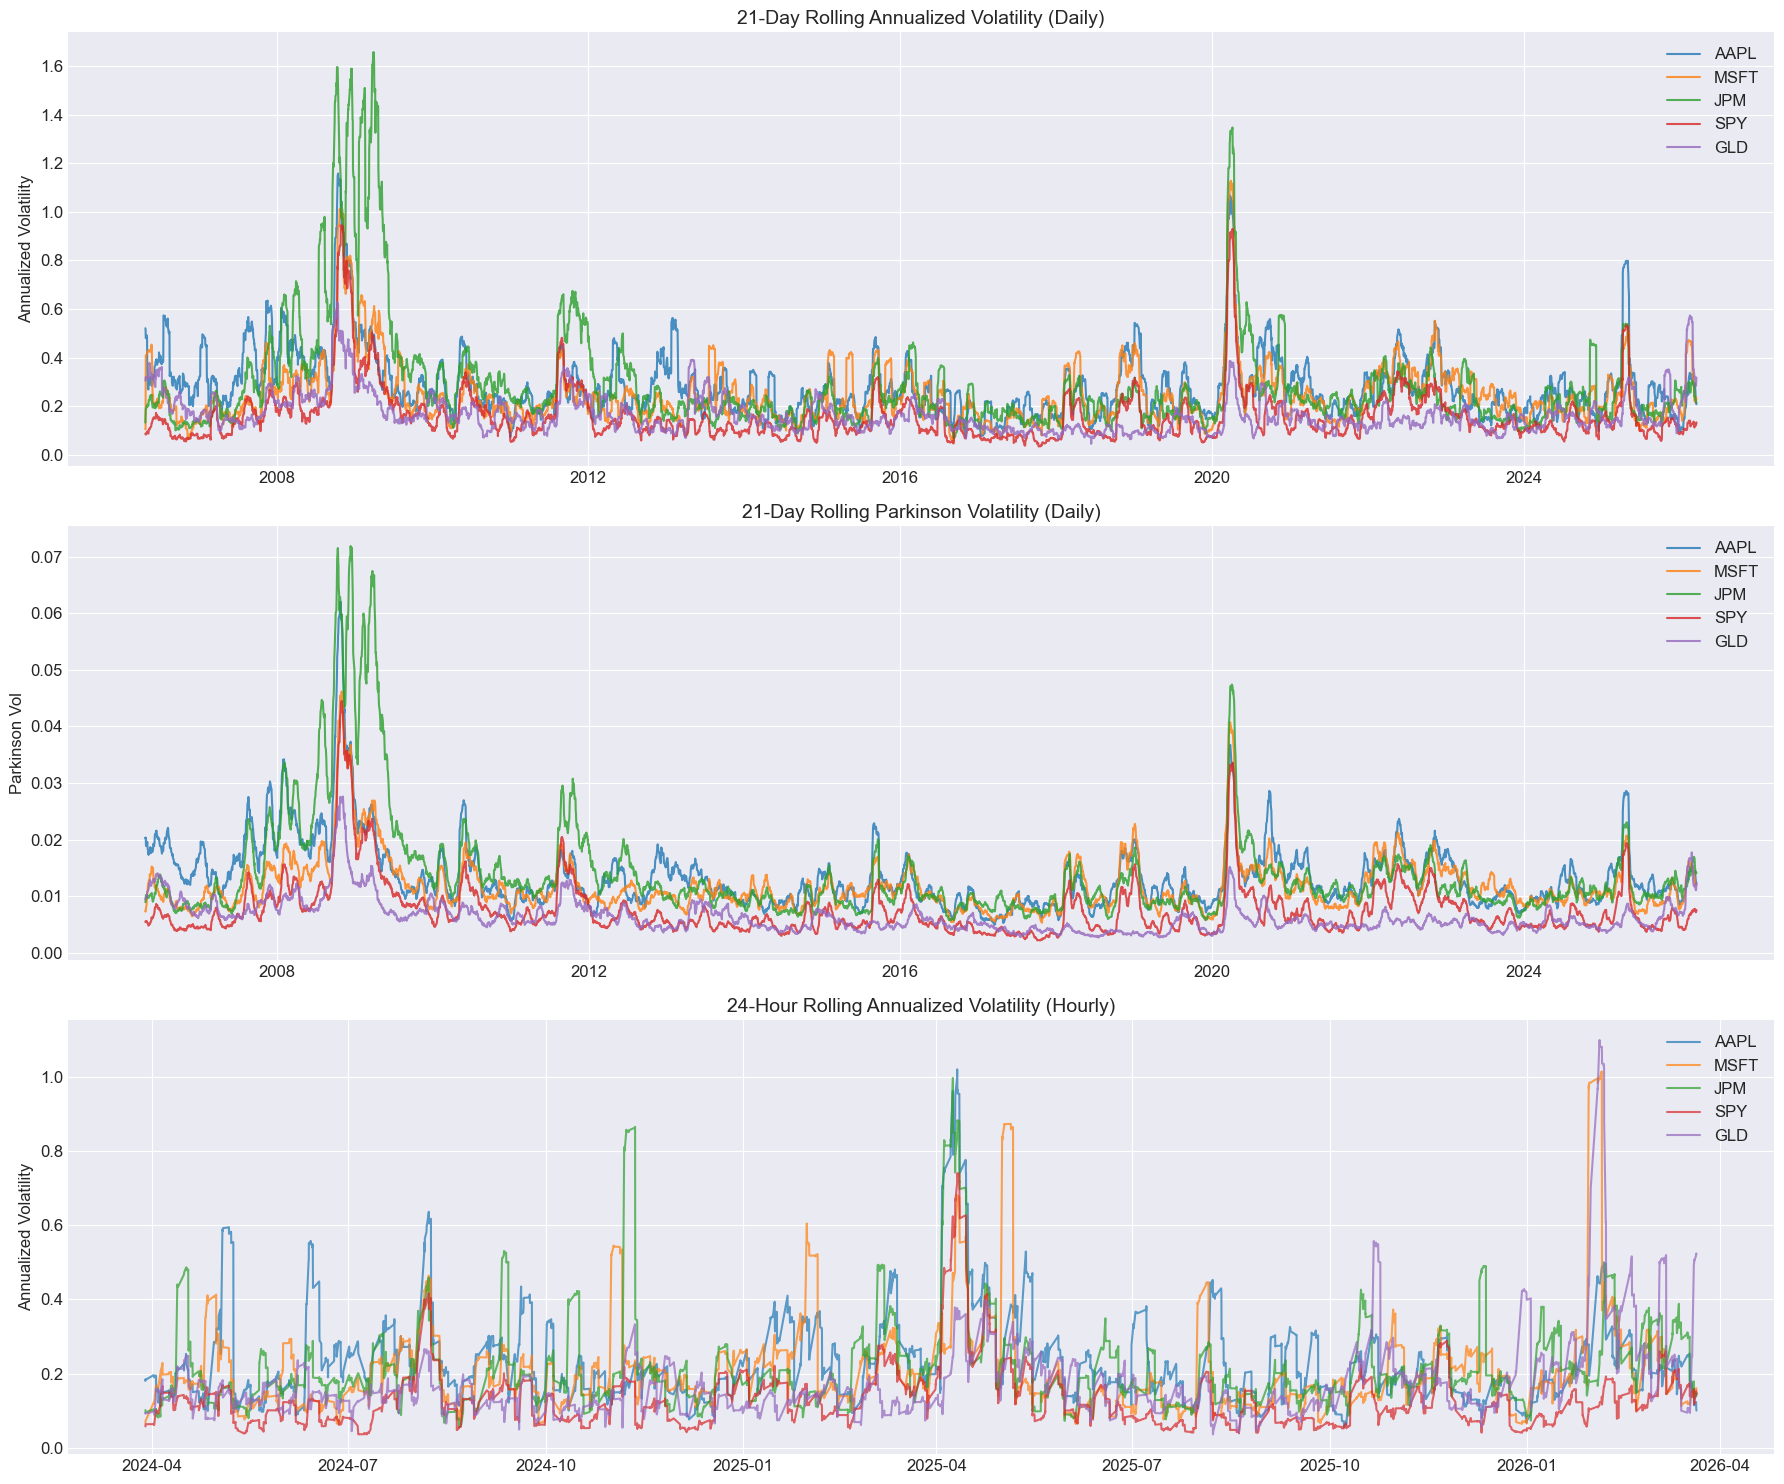

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(18, 15))

# Rolling 21-day volatility (annualized)
for t in TICKERS:
    rolling_vol = daily_returns[t].rolling(21).std() * np.sqrt(252)
    axes[0].plot(rolling_vol.index, rolling_vol, label=t, alpha=0.8)
axes[0].set_title('21-Day Rolling Annualized Volatility (Daily)')
axes[0].set_ylabel('Annualized Volatility')
axes[0].legend()

# Parkinson volatility (daily)
for t in TICKERS:
    df = daily_data[t]
    parkinson = np.sqrt((1 / (4 * np.log(2))) * (np.log(df['High'] / df['Low']) ** 2))
    parkinson_roll = parkinson.rolling(21).mean()
    axes[1].plot(parkinson_roll.index, parkinson_roll, label=t, alpha=0.8)
axes[1].set_title('21-Day Rolling Parkinson Volatility (Daily)')
axes[1].set_ylabel('Parkinson Vol')
axes[1].legend()

# Hourly rolling volatility
for t in TICKERS:
    rolling_vol_h = hourly_returns[t].rolling(24).std() * np.sqrt(252 * 6.5)
    axes[2].plot(rolling_vol_h.index, rolling_vol_h, label=t, alpha=0.7)
axes[2].set_title('24-Hour Rolling Annualized Volatility (Hourly)')
axes[2].set_ylabel('Annualized Volatility')
axes[2].legend()

plt.tight_layout()
plt.show()

## 11. Drawdown Analysis


Drawdowns measure the decline from a historical peak and are the primary concern of risk management. Maximum Drawdown (MDD) quantifies the worst-case loss an investor would have experienced. Understanding the depth and duration of drawdowns is essential for setting the stop-loss barriers in the Triple Barrier Method (Phase 3).

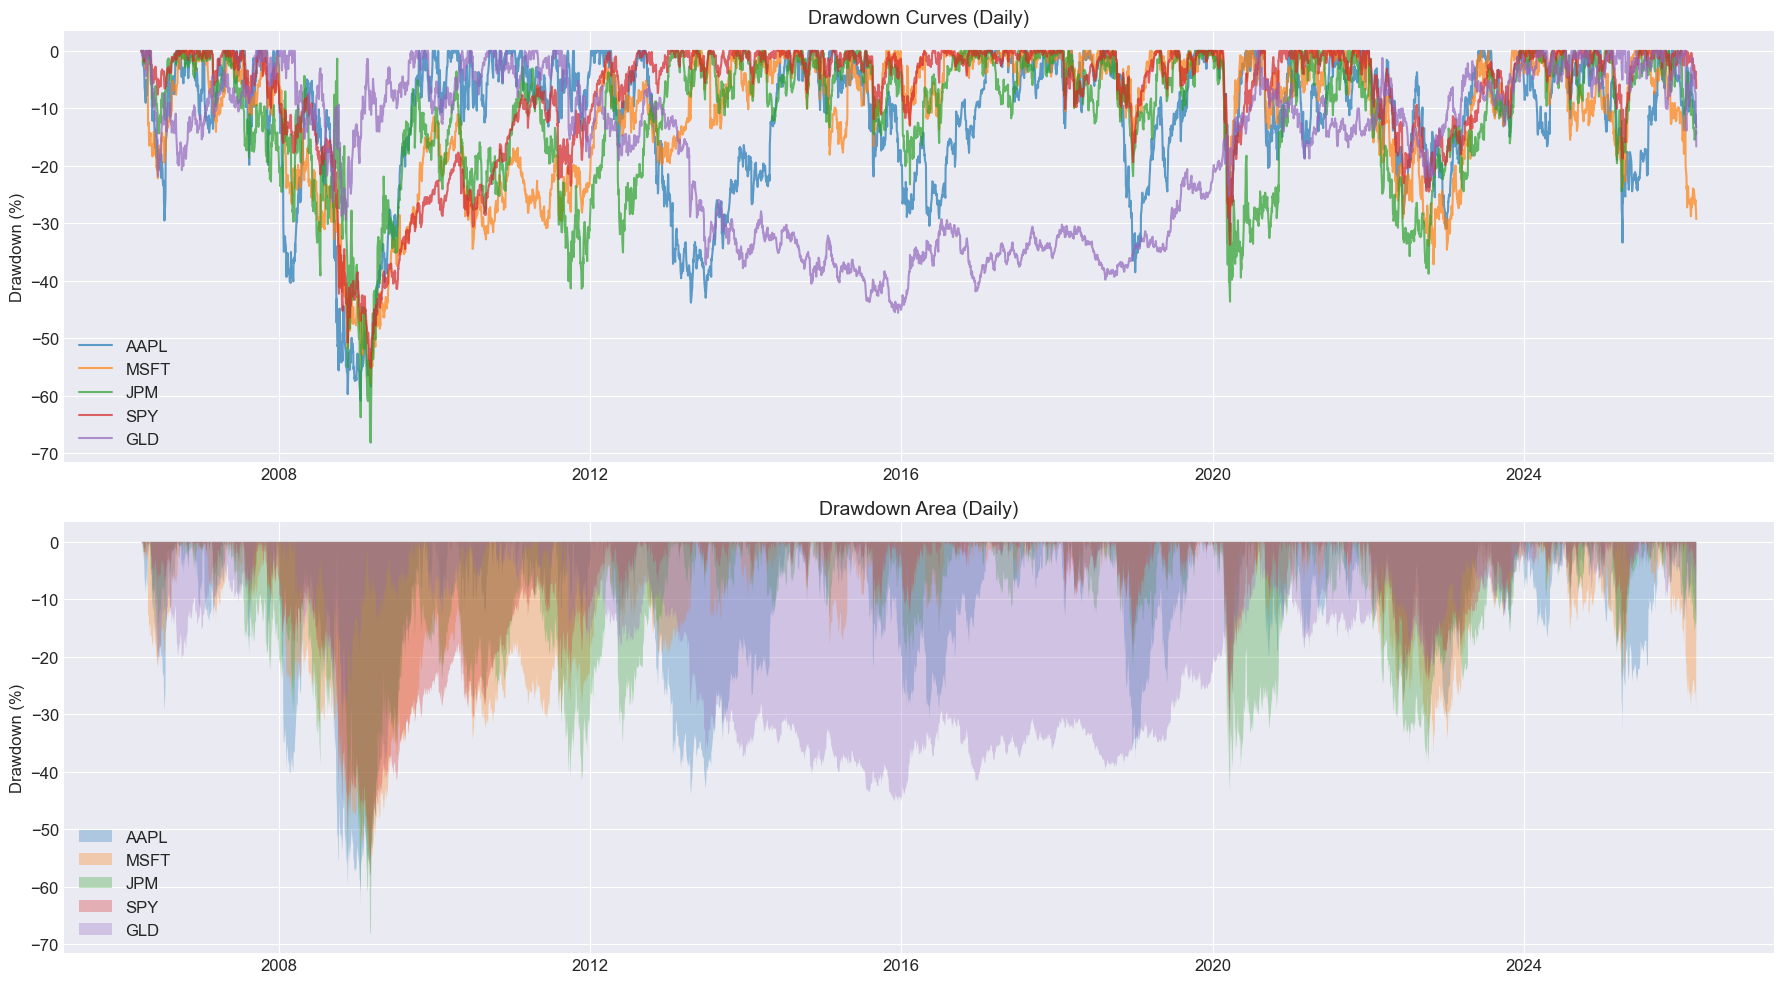

,Ticker,Max Drawdown,Avg Drawdown,Max DD Date,Recovery Days
0,AAPL,-60.87%,-11.49%,2009-01-20,274
1,MSFT,-57.94%,-10.96%,2009-03-09,1513
2,JPM,-68.15%,-11.19%,2009-03-09,1409
3,SPY,-55.19%,-7.48%,2009-03-09,1256
4,GLD,-45.56%,-17.00%,2015-12-17,1686


In [11]:
fig, axes = plt.subplots(2, 1, figsize=(18, 10))

drawdown_stats = []
for t in TICKERS:
    cum_ret = (1 + daily_returns[t]).cumprod()
    running_max = cum_ret.cummax()
    drawdown = (cum_ret - running_max) / running_max
    
    axes[0].plot(drawdown.index, drawdown * 100, label=t, alpha=0.7)
    axes[1].fill_between(drawdown.index, drawdown * 100, 0, alpha=0.3, label=t)
    
    drawdown_stats.append({
        "Ticker": t,
        "Max Drawdown": f"{drawdown.min() * 100:.2f}%",
        "Avg Drawdown": f"{drawdown.mean() * 100:.2f}%",
        "Max DD Date": str(drawdown.idxmin().date()),
        "Recovery Days": int((drawdown[drawdown.idxmin():] == 0).idxmax().toordinal() - drawdown.idxmin().toordinal()) if (drawdown[drawdown.idxmin():] == 0).any() else "Not Recovered"
    })

axes[0].set_title('Drawdown Curves (Daily)')
axes[0].set_ylabel('Drawdown (%)')
axes[0].legend()
axes[1].set_title('Drawdown Area (Daily)')
axes[1].set_ylabel('Drawdown (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

pd.DataFrame(drawdown_stats)

## 12. Cross-Asset Correlation Analysis


Understanding the co-movement between assets is fundamental for portfolio construction and risk management. We compute the full correlation matrix of daily returns and visualize it as a heatmap. We also examine **rolling correlations** to understand how relationships between assets change over time -- correlations tend to spike toward 1.0 during market crashes (the "correlation breakdown" phenomenon).

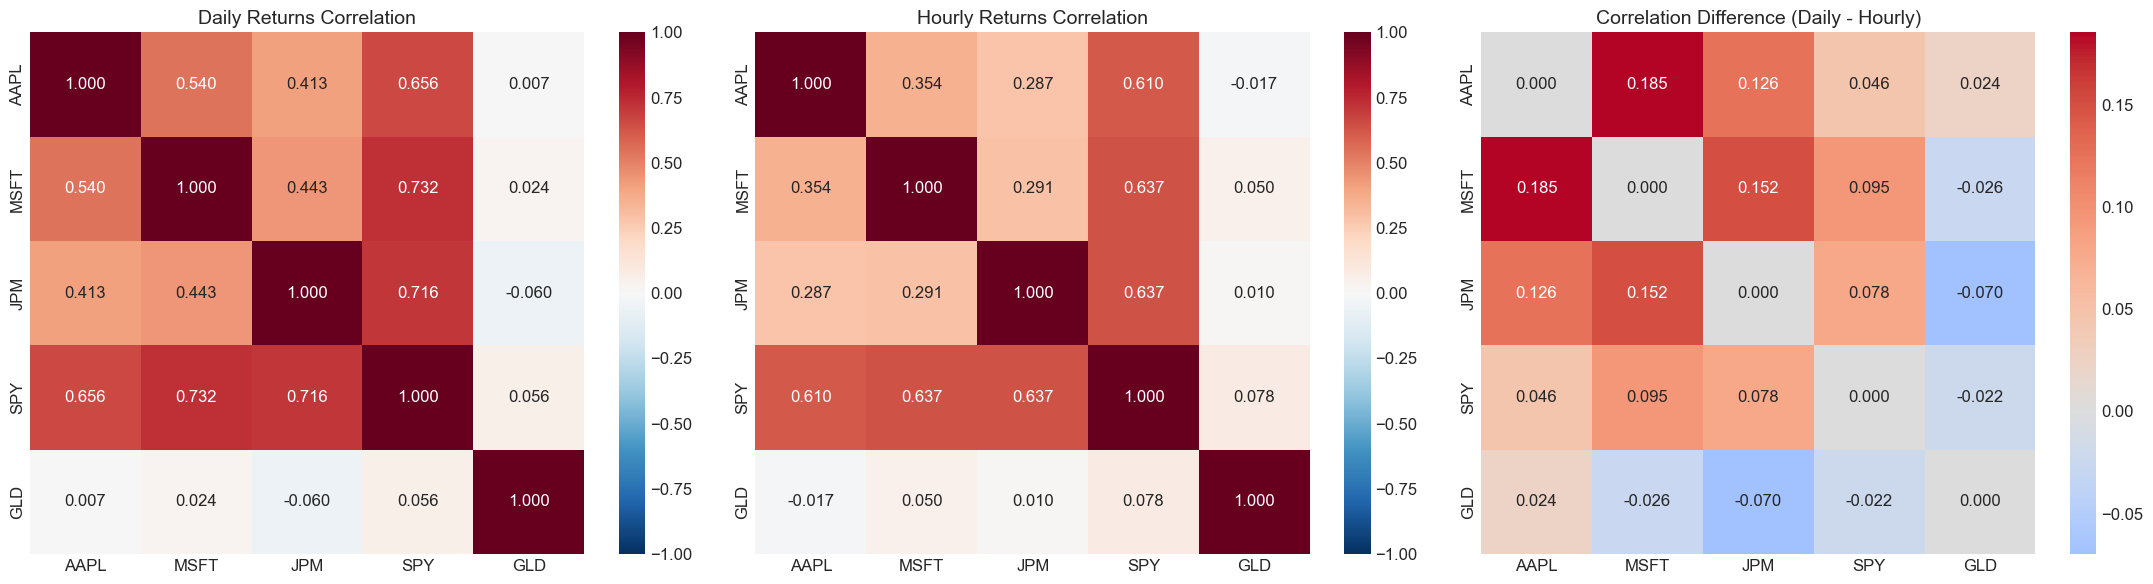

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Static correlation matrix (daily)
daily_ret_df = pd.DataFrame(daily_returns)
corr_matrix = daily_ret_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=axes[0], fmt='.3f')
axes[0].set_title('Daily Returns Correlation')

# Static correlation matrix (hourly)
hourly_ret_df = pd.DataFrame(hourly_returns)
corr_matrix_h = hourly_ret_df.corr()
sns.heatmap(corr_matrix_h, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=axes[1], fmt='.3f')
axes[1].set_title('Hourly Returns Correlation')

# Difference
diff_corr = corr_matrix - corr_matrix_h
sns.heatmap(diff_corr, annot=True, cmap='coolwarm', center=0, ax=axes[2], fmt='.3f')
axes[2].set_title('Correlation Difference (Daily - Hourly)')

plt.tight_layout()
plt.show()

## 13. Rolling Correlations and Regime Dynamics


Static correlations hide the most important information: how relationships evolve during stress. We compute 63-day (quarterly) rolling correlations between selected pairs to identify periods where diversification fails. A spike in correlation between traditionally uncorrelated assets (e.g., SPY and GLD) signals a flight-to-liquidity event.

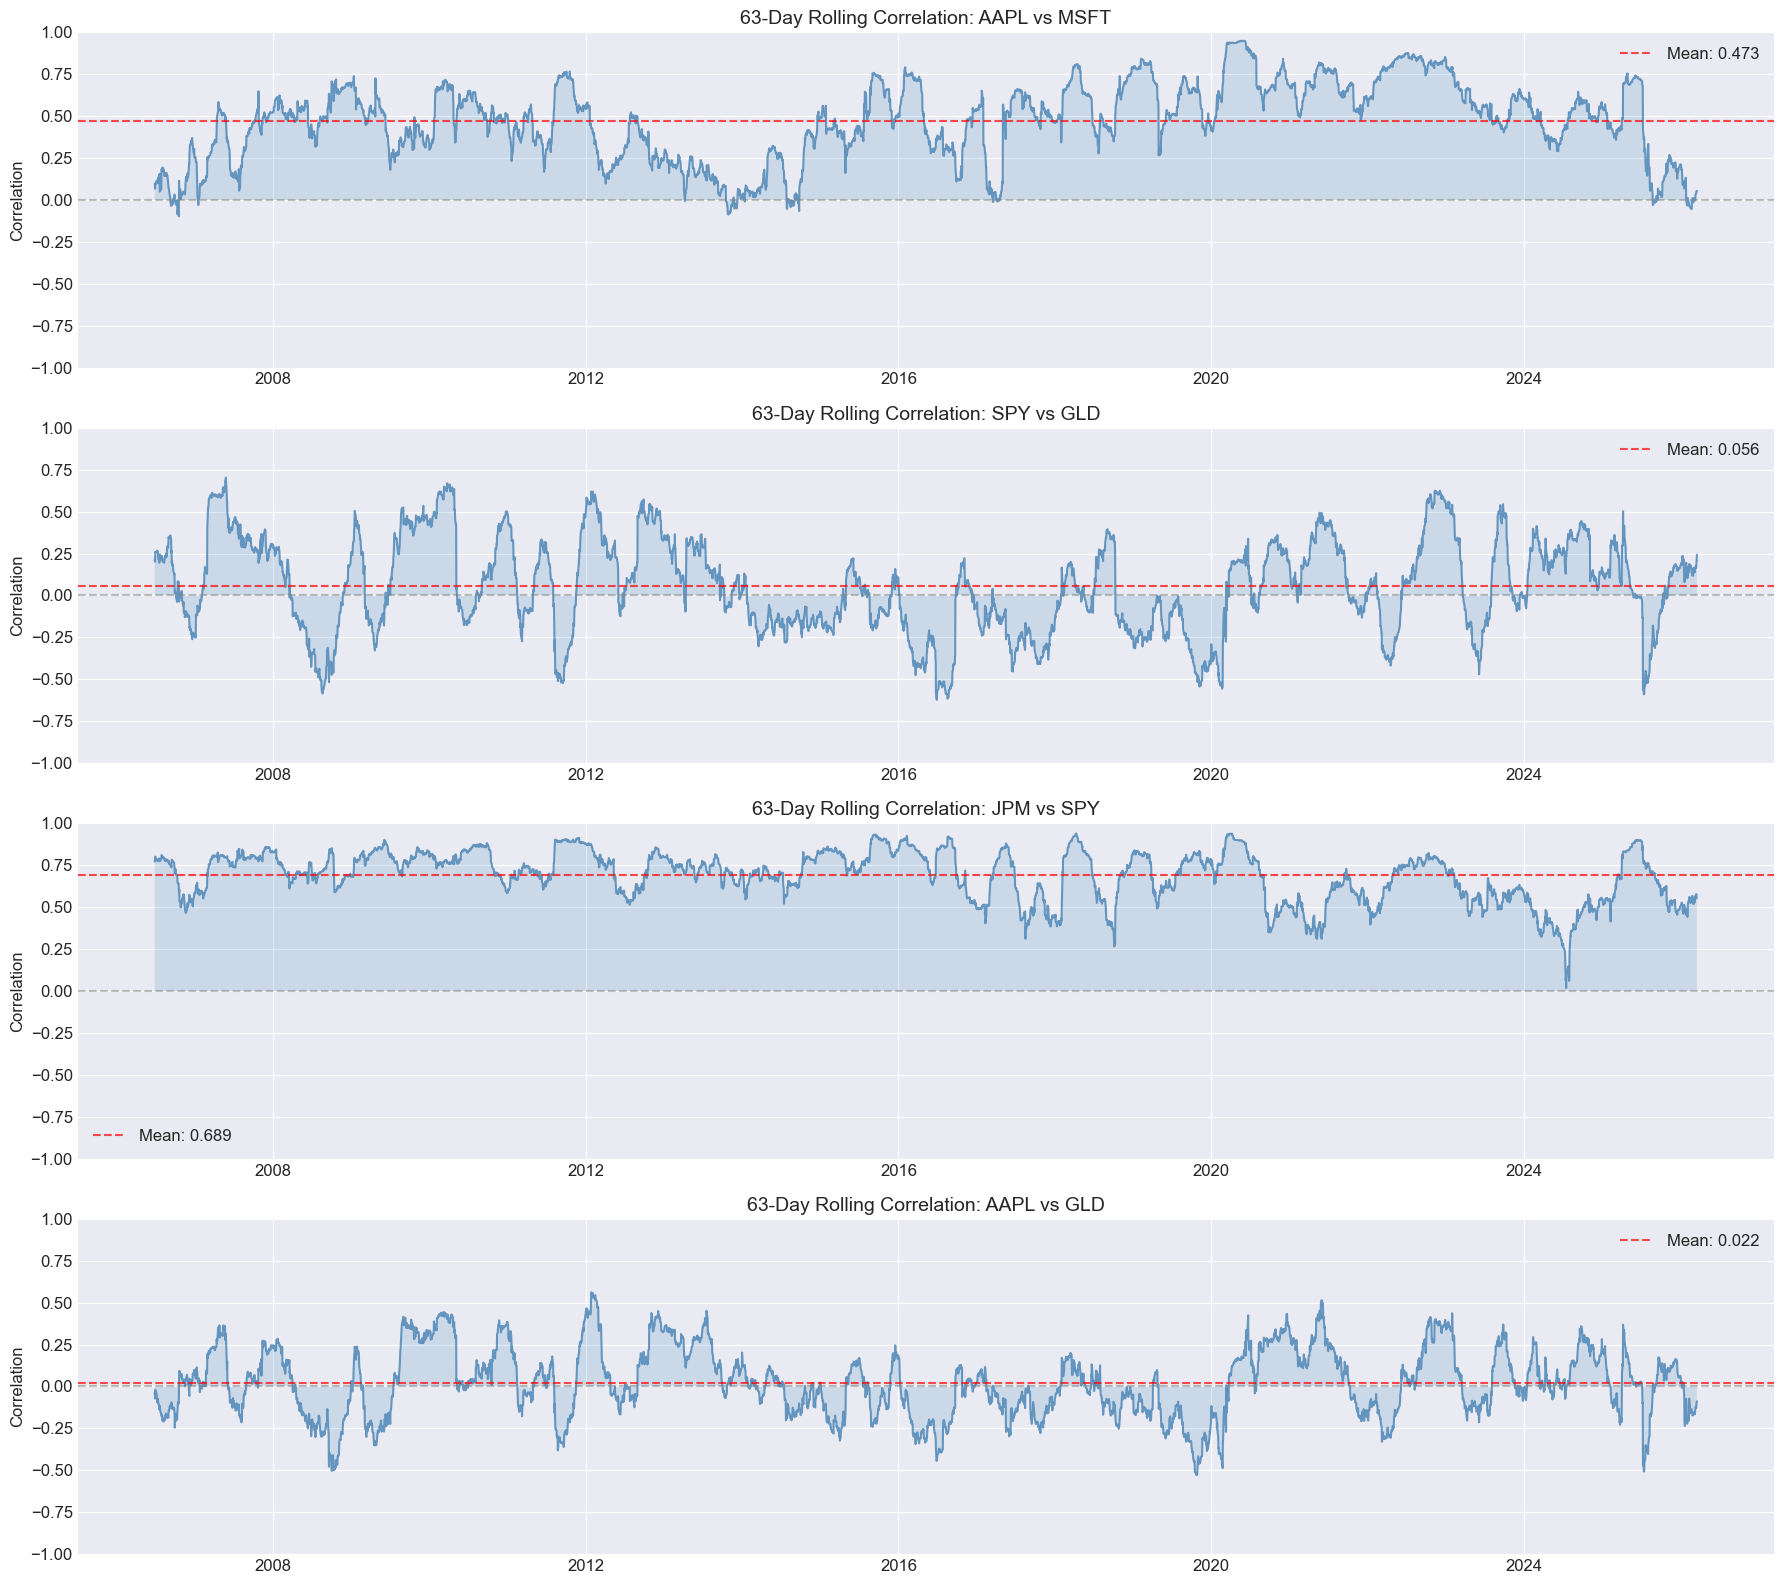

In [13]:
pairs = [("AAPL", "MSFT"), ("SPY", "GLD"), ("JPM", "SPY"), ("AAPL", "GLD")]

fig, axes = plt.subplots(len(pairs), 1, figsize=(18, 4 * len(pairs)))

for i, (a, b) in enumerate(pairs):
    rolling_corr = daily_returns[a].rolling(63).corr(daily_returns[b])
    axes[i].plot(rolling_corr.index, rolling_corr, color='steelblue', alpha=0.8)
    axes[i].axhline(y=0, color='grey', linestyle='--', alpha=0.5)
    axes[i].axhline(y=rolling_corr.mean(), color='red', linestyle='--', alpha=0.7, label=f'Mean: {rolling_corr.mean():.3f}')
    axes[i].fill_between(rolling_corr.index, rolling_corr, 0, alpha=0.15)
    axes[i].set_title(f'63-Day Rolling Correlation: {a} vs {b}')
    axes[i].set_ylabel('Correlation')
    axes[i].legend()
    axes[i].set_ylim(-1, 1)

plt.tight_layout()
plt.show()

## 14. Volume Analysis and Volume-Price Dynamics


Volume is the often-overlooked "third dimension" of market data. High volume confirms price movements, while divergences between price and volume can signal reversals. We examine volume trends over time and the relationship between volume and absolute returns (a proxy for activity-driven volatility).

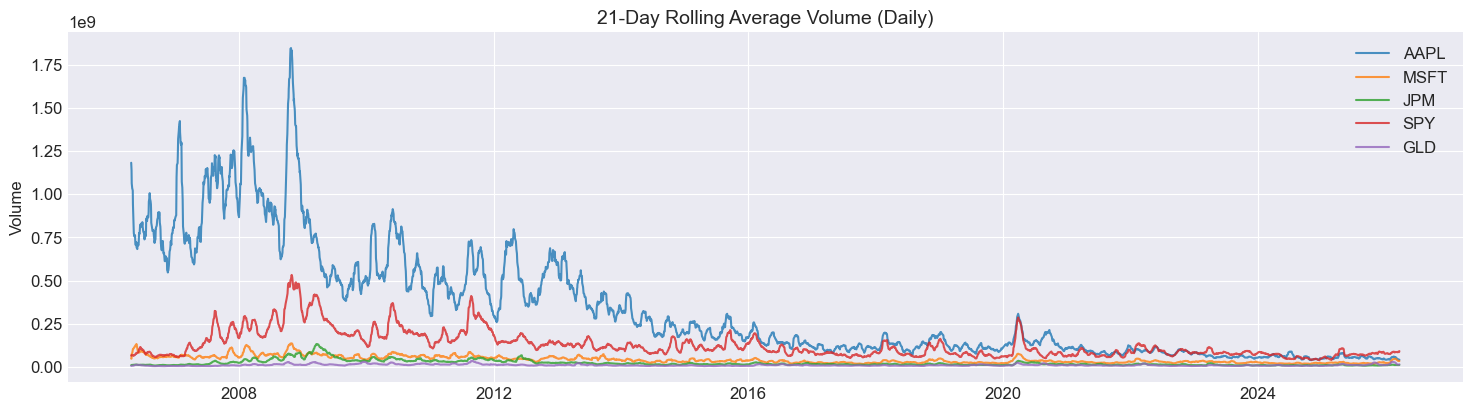

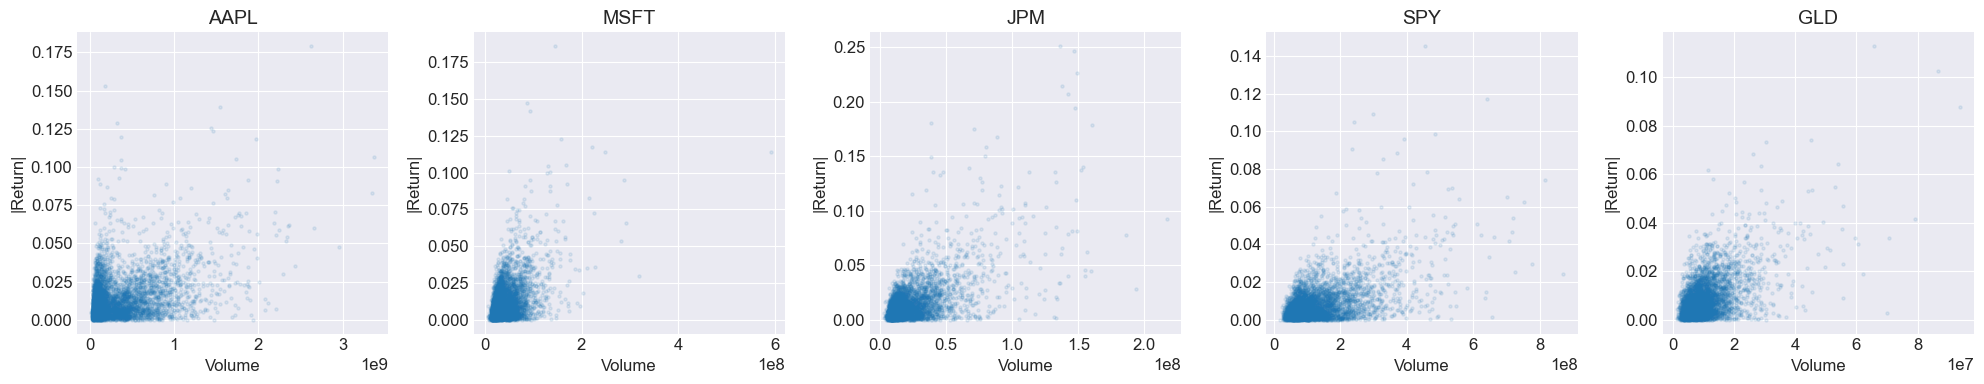

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(18, 10))

# Volume over time (daily)
for t in TICKERS:
    vol_ma = daily_data[t]['Volume'].rolling(21).mean()
    axes[0].plot(vol_ma.index, vol_ma, label=t, alpha=0.8)
axes[0].set_title('21-Day Rolling Average Volume (Daily)')
axes[0].set_ylabel('Volume')
axes[0].legend()

# Volume vs Absolute Returns scatter
fig2, axes2 = plt.subplots(1, len(TICKERS), figsize=(4 * len(TICKERS), 4))
for i, t in enumerate(TICKERS):
    abs_rets = daily_returns[t].abs()
    vol = daily_data[t]['Volume'].reindex(abs_rets.index)
    axes2[i].scatter(vol, abs_rets, alpha=0.1, s=5)
    axes2[i].set_title(f'{t}')
    axes2[i].set_xlabel('Volume')
    axes2[i].set_ylabel('|Return|')

axes[1].set_visible(False)
plt.tight_layout()
plt.show()
fig2.suptitle('Volume vs Absolute Returns', fontsize=14, y=1.02)
fig2.tight_layout()
fig2.savefig('../data/processed/volume_vs_returns.png', bbox_inches='tight', dpi=100)
plt.show()

## 15. Temporal Seasonality Patterns


Financial markets exhibit well-documented seasonal patterns. The "Monday Effect" (historically negative Monday returns), the "January Effect" (small-cap outperformance in January), and intra-day patterns all provide valuable features for the forecaster. We decompose returns by day-of-week, month-of-year, and (for hourly data) hour-of-day to uncover any exploitable regularities.

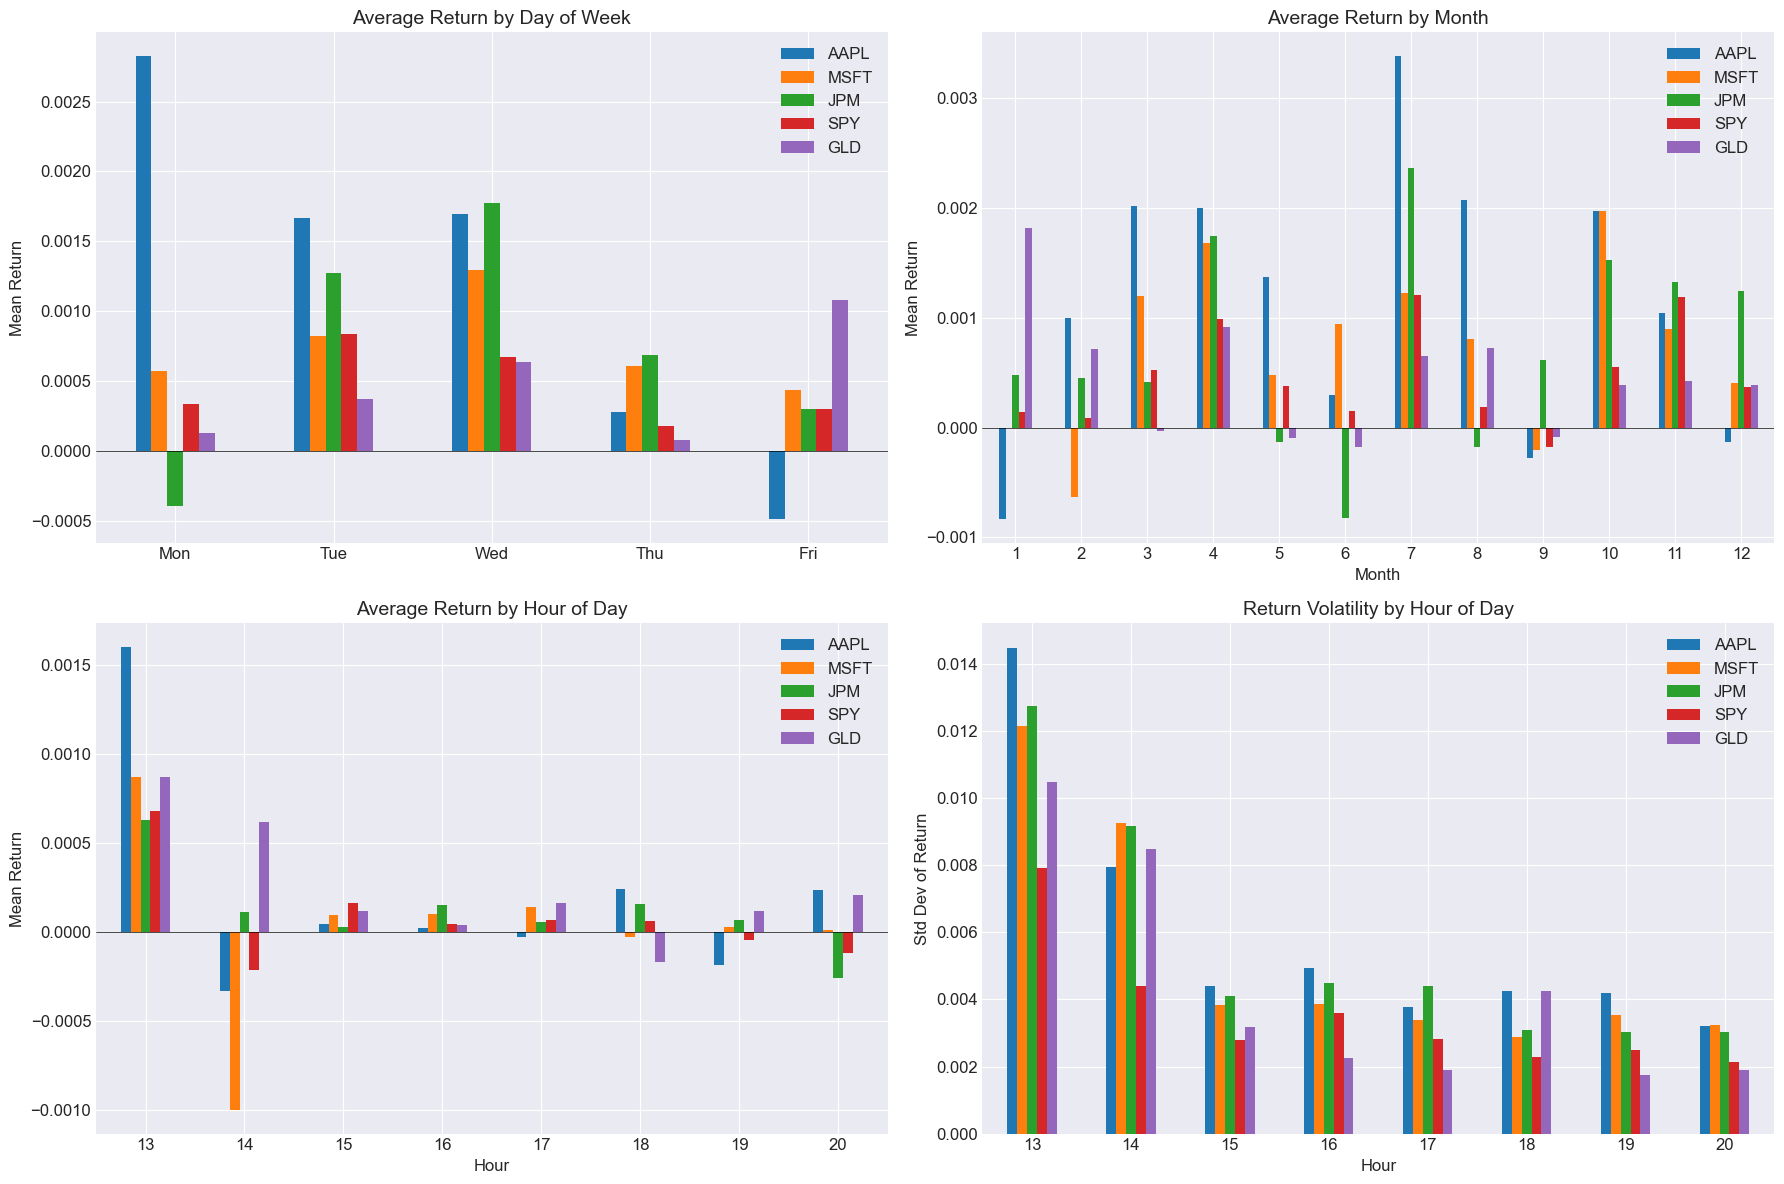

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Day of week effect (daily)
dow_returns = pd.DataFrame(daily_returns)
dow_returns['DayOfWeek'] = dow_returns.index.dayofweek
dow_means = dow_returns.groupby('DayOfWeek')[TICKERS].mean()
dow_means.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']
dow_means.plot(kind='bar', ax=axes[0, 0], rot=0)
axes[0, 0].set_title('Average Return by Day of Week')
axes[0, 0].set_ylabel('Mean Return')
axes[0, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Month of year effect (daily)
monthly_returns = pd.DataFrame(daily_returns)
monthly_returns['Month'] = monthly_returns.index.month
month_means = monthly_returns.groupby('Month')[TICKERS].mean()
month_means.plot(kind='bar', ax=axes[0, 1], rot=0)
axes[0, 1].set_title('Average Return by Month')
axes[0, 1].set_ylabel('Mean Return')
axes[0, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Hour of day effect (hourly)
hourly_ret_df_ts = pd.DataFrame(hourly_returns)
hourly_ret_df_ts['Hour'] = hourly_ret_df_ts.index.hour
hour_means = hourly_ret_df_ts.groupby('Hour')[TICKERS].mean()
hour_means.plot(kind='bar', ax=axes[1, 0], rot=0)
axes[1, 0].set_title('Average Return by Hour of Day')
axes[1, 0].set_ylabel('Mean Return')
axes[1, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Hourly volatility by hour
hourly_vol_by_hour = hourly_ret_df_ts.groupby('Hour')[TICKERS].std()
hourly_vol_by_hour.plot(kind='bar', ax=axes[1, 1], rot=0)
axes[1, 1].set_title('Return Volatility by Hour of Day')
axes[1, 1].set_ylabel('Std Dev of Return')

plt.tight_layout()
plt.show()

## 16. Tail Risk: Value at Risk (VaR) and Conditional VaR


Traditional volatility measures (standard deviation) assume symmetric, well-behaved distributions. Financial distributions are neither. Value at Risk (VaR) estimates the maximum loss at a given confidence level, while Conditional VaR (CVaR, or Expected Shortfall) measures the average loss in the worst-case tail. These metrics are critical for setting the stop-loss barriers in Phase 3.

In [16]:
confidence_levels = [0.95, 0.99]
risk_metrics = []

for t in TICKERS:
    rets = daily_returns[t]
    for cl in confidence_levels:
        var = np.percentile(rets, (1 - cl) * 100)
        cvar = rets[rets <= var].mean()
        risk_metrics.append({
            "Ticker": t,
            "Confidence": f"{cl*100:.0f}%",
            "VaR (Daily)": f"{var*100:.3f}%",
            "CVaR (Daily)": f"{cvar*100:.3f}%",
        })

pd.DataFrame(risk_metrics)

,Ticker,Confidence,VaR (Daily),CVaR (Daily)
0,AAPL,95%,-2.941%,-4.494%
1,AAPL,99%,-5.397%,-7.215%
2,MSFT,95%,-2.592%,-3.966%
3,MSFT,99%,-4.552%,-6.663%
4,JPM,95%,-3.055%,-5.192%
5,JPM,99%,-6.219%,-9.427%
6,SPY,95%,-1.801%,-2.983%
7,SPY,99%,-3.572%,-5.203%
8,GLD,95%,-1.784%,-2.728%
9,GLD,99%,-3.162%,-4.484%


## 17. Hurst Exponent: Mean-Reversion vs. Trending


The Hurst Exponent ($H$) reveals the fundamental character of a time-series:
- $H < 0.5$: Mean-reverting (anti-persistent). The series tends to reverse direction.
- $H = 0.5$: Random walk. No exploitable pattern.
- $H > 0.5$: Trending (persistent). The series tends to continue in its current direction.


This is directly related to the Fractional Differentiation parameter $d$ from our research document. If a series is trending ($H > 0.5$), it carries "memory" that FracDiff can preserve.

In [17]:
def compute_hurst(series, max_lag=100):
    """Compute the Hurst exponent using the R/S method."""
    series = series.dropna().values
    lags = range(2, max_lag)
    tau = []
    for lag in lags:
        chunks = [series[i:i+lag] for i in range(0, len(series) - lag, lag)]
        rs_values = []
        for chunk in chunks:
            if len(chunk) < lag:
                continue
            mean_val = np.mean(chunk)
            deviations = chunk - mean_val
            cumulative = np.cumsum(deviations)
            r = np.max(cumulative) - np.min(cumulative)
            s = np.std(chunk, ddof=1)
            if s > 0:
                rs_values.append(r / s)
        if rs_values:
            tau.append(np.mean(rs_values))
        else:
            tau.append(np.nan)
    
    valid = [(l, t) for l, t in zip(lags, tau) if not np.isnan(t) and t > 0]
    if len(valid) < 2:
        return np.nan
    log_lags = np.log([v[0] for v in valid])
    log_tau = np.log([v[1] for v in valid])
    hurst = np.polyfit(log_lags, log_tau, 1)[0]
    return hurst

hurst_results = []
for t in TICKERS:
    h_price = compute_hurst(daily_data[t]['Close'])
    h_return = compute_hurst(daily_returns[t])
    h_hourly = compute_hurst(hourly_returns[t])
    hurst_results.append({
        "Ticker": t,
        "H (Price)": f"{h_price:.4f}",
        "H (Daily Returns)": f"{h_return:.4f}",
        "H (Hourly Returns)": f"{h_hourly:.4f}",
        "Price Behavior": "Trending" if h_price > 0.55 else ("Mean-Reverting" if h_price < 0.45 else "Random Walk"),
        "Return Behavior": "Trending" if h_return > 0.55 else ("Mean-Reverting" if h_return < 0.45 else "Random Walk")
    })

pd.DataFrame(hurst_results)

,Ticker,H (Price),H (Daily Returns),H (Hourly Returns),Price Behavior,Return Behavior
0,AAPL,1.0114,0.6371,0.6405,Trending,Trending
1,MSFT,1.0178,0.6005,0.6000,Trending,Trending
2,JPM,1.0074,0.6242,0.6173,Trending,Trending
3,SPY,1.0179,0.6098,0.6157,Trending,Trending
4,GLD,1.0088,0.6435,0.6138,Trending,Trending


## 18. Leverage Effect: Asymmetric Volatility Response


The "leverage effect" refers to the empirical observation that negative returns increase volatility more than positive returns of the same magnitude. This asymmetry is critical for GARCH modeling (Phase 4) and for the GJR-GARCH diagnostic in Phase 6. We measure this by computing the correlation between returns and future squared returns.

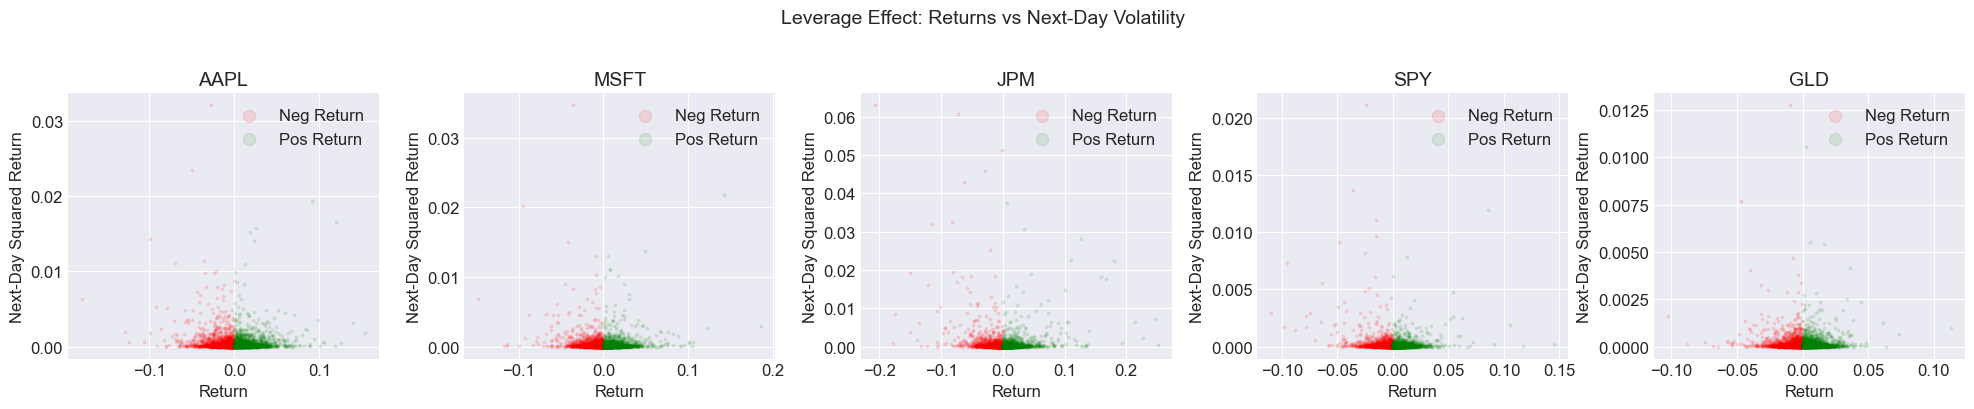

,Ticker,"Corr(r_t, r_{t+1}^2)",Avg Vol After Neg,Avg Vol After Pos,Ratio (Neg/Pos)
0,AAPL,-0.0585,0.000453,0.000347,1.31x
1,MSFT,-0.0465,0.000343,0.000271,1.27x
2,JPM,-0.0858,0.000643,0.000440,1.46x
3,SPY,-0.1124,0.000195,0.000113,1.73x
4,GLD,-0.0358,0.000142,0.000124,1.14x


In [18]:
fig, axes = plt.subplots(1, len(TICKERS), figsize=(4 * len(TICKERS), 4))

leverage_stats = []
for i, t in enumerate(TICKERS):
    rets = daily_returns[t]
    future_vol = (rets ** 2).shift(-1)
    
    combined = pd.DataFrame({'Return': rets, 'Future_Vol': future_vol}).dropna()
    neg_mask = combined['Return'] < 0
    pos_mask = combined['Return'] > 0
    
    neg_vol = combined.loc[neg_mask, 'Future_Vol'].mean()
    pos_vol = combined.loc[pos_mask, 'Future_Vol'].mean()
    leverage_corr = combined['Return'].corr(combined['Future_Vol'])
    
    leverage_stats.append({
        "Ticker": t,
        "Corr(r_t, r_{t+1}^2)": f"{leverage_corr:.4f}",
        "Avg Vol After Neg": f"{neg_vol:.6f}",
        "Avg Vol After Pos": f"{pos_vol:.6f}",
        "Ratio (Neg/Pos)": f"{neg_vol/pos_vol:.2f}x"
    })
    
    axes[i].scatter(combined.loc[neg_mask, 'Return'], combined.loc[neg_mask, 'Future_Vol'], 
                    alpha=0.1, s=3, c='red', label='Neg Return')
    axes[i].scatter(combined.loc[pos_mask, 'Return'], combined.loc[pos_mask, 'Future_Vol'],
                    alpha=0.1, s=3, c='green', label='Pos Return')
    axes[i].set_title(f'{t}')
    axes[i].set_xlabel('Return')
    axes[i].set_ylabel('Next-Day Squared Return')
    axes[i].legend(markerscale=5)

plt.suptitle('Leverage Effect: Returns vs Next-Day Volatility', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

pd.DataFrame(leverage_stats)

## 19. Ljung-Box Test for Serial Correlation


The Ljung-Box Q-test formally tests whether a group of autocorrelations of a time series are different from zero. We test both returns (should show no autocorrelation if markets are efficient) and squared returns (should show autocorrelation due to volatility clustering). This test will also be a key diagnostic in Phase 6.

In [19]:
lb_results = []
for t in TICKERS:
    for name, series in [("Returns", daily_returns[t]), ("Sq Returns", daily_returns[t] ** 2)]:
        lb = acorr_ljungbox(series.dropna(), lags=10, return_df=True)
        lb_results.append({
            "Ticker": t,
            "Series": name,
            "Q(5)": f"{lb.iloc[4]['lb_stat']:.2f}",
            "p(5)": f"{lb.iloc[4]['lb_pvalue']:.4f}",
            "Q(10)": f"{lb.iloc[9]['lb_stat']:.2f}",
            "p(10)": f"{lb.iloc[9]['lb_pvalue']:.4f}",
            "Autocorrelated?": "Yes" if lb.iloc[9]['lb_pvalue'] < 0.05 else "No"
        })

pd.DataFrame(lb_results)

,Ticker,Series,Q(5),p(5),Q(10),p(10),Autocorrelated?
0,AAPL,Returns,7.62,0.1785,32.51,0.0003,Yes
1,AAPL,Sq Returns,705.66,0.0000,1421.57,0.0000,Yes
2,MSFT,Returns,68.62,0.0000,103.98,0.0000,Yes
3,MSFT,Sq Returns,761.41,0.0000,1251.85,0.0000,Yes
4,JPM,Returns,65.18,0.0000,99.93,0.0000,Yes
5,JPM,Sq Returns,1618.19,0.0000,2816.48,0.0000,Yes
6,SPY,Returns,64.14,0.0000,95.34,0.0000,Yes
7,SPY,Sq Returns,2294.03,0.0000,3844.86,0.0000,Yes
8,GLD,Returns,2.31,0.8052,7.93,0.6353,No
9,GLD,Sq Returns,395.75,0.0000,685.38,0.0000,Yes


## 20. Cumulative Returns and Risk-Adjusted Performance


Finally, we place all assets on an equal footing by comparing their cumulative returns and basic risk-adjusted metrics over the full 20-year sample. The Sharpe Ratio (annualized return divided by annualized volatility) provides the simplest risk-adjusted performance measure and will serve as the primary benchmark for our ML models in later phases.

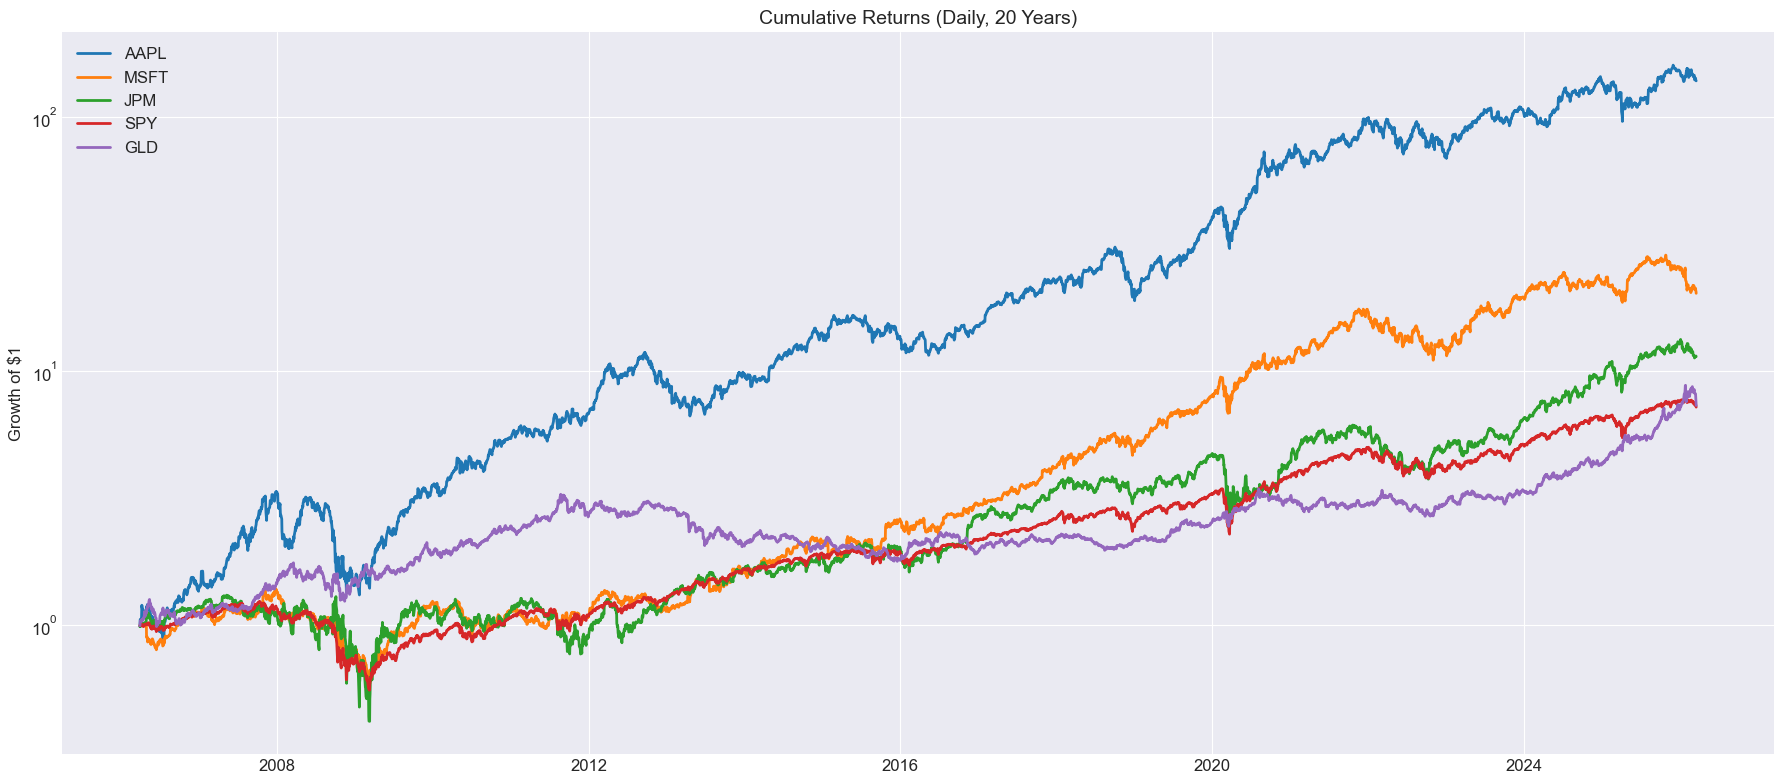

,Ticker,Total Return,Annualized Return,Annualized Vol,Sharpe Ratio,Max Drawdown
0,AAPL,13807.8%,29.73%,31.56%,0.942,-60.9%
1,MSFT,1925.4%,18.90%,27.65%,0.684,-57.9%
2,JPM,1041.6%,18.90%,36.76%,0.514,-68.1%
3,SPY,621.7%,11.79%,19.41%,0.608,-55.2%
4,GLD,633.1%,11.66%,18.25%,0.639,-45.6%


In [20]:
fig, ax = plt.subplots(figsize=(18, 8))

perf_summary = []
for t in TICKERS:
    cum = (1 + daily_returns[t]).cumprod()
    ax.plot(cum.index, cum, label=t, linewidth=2)
    
    ann_ret = daily_returns[t].mean() * 252
    ann_vol = daily_returns[t].std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    
    perf_summary.append({
        "Ticker": t,
        "Total Return": f"{(cum.iloc[-1] - 1) * 100:.1f}%",
        "Annualized Return": f"{ann_ret * 100:.2f}%",
        "Annualized Vol": f"{ann_vol * 100:.2f}%",
        "Sharpe Ratio": f"{sharpe:.3f}",
        "Max Drawdown": f"{((cum / cum.cummax()) - 1).min() * 100:.1f}%"
    })

ax.set_title('Cumulative Returns (Daily, 20 Years)')
ax.set_ylabel('Growth of $1')
ax.legend(fontsize=12)
ax.set_yscale('log')
plt.tight_layout()
plt.show()

pd.DataFrame(perf_summary)

## 21. Summary and Key Findings


This concludes the exhaustive EDA phase. The key findings that will inform subsequent phases are:


1. **Non-Normality**: All assets exhibit significant fat tails and negative skewness. Standard deviation alone is an inadequate risk measure; Huber Loss is justified.
2. **Non-Stationarity**: Raw prices are non-stationary, returns are stationary. Fractional Differentiation will bridge this gap.
3. **Volatility Clustering**: Squared returns show strong autocorrelation (confirmed by Ljung-Box). GARCH modeling is warranted.
4. **Leverage Effect**: Negative returns produce disproportionately higher future volatility. GJR-GARCH or asymmetric models are needed.
5. **Hurst Exponents**: Price series tend to be trending (H > 0.5), confirming the presence of exploitable "memory."
6. **Seasonal Patterns**: Day-of-week and intraday patterns exist and should be included as features.
7. **Tail Risk**: VaR and CVaR quantify the extreme losses that the Triple Barrier stop-loss must guard against.
8. **Cross-Horizon Differences**: Daily and hourly correlations differ, justifying the dual-model architecture.


The next phase (Phase 3: Feature Engineering) will use these insights to construct the optimal feature space for our ML engines.